In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
from matplotlib.colors import Normalize
import matplotlib as mpl
import numpy as np
import os
from itertools import groupby
import shutil
from blimpy import Waterfall
from functools import partial
import gc
from tqdm import tqdm
from multiprocessing import Pool
import random
import math
from astropy.visualization import ZScaleInterval
from scipy.stats import norm
from scipy.signal import savgol_filter
from copy import deepcopy

plt.rcParams.update({'font.size': 12})

In [2]:
%matplotlib inline

In [3]:
table = pd.read_table('/home/bhanselman-test/x_0002_sed.out', delimiter='|').dropna()
unspliced_table = table[table.iloc[:, 8] == 64]
unspliced_table

/tmp/ipykernel_1833562/3021517675.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  table = pd.read_table('/home/bhanselman-test/x_0002_sed.out', delimiter='|').dropna()


,id,observation_id,format,size,freq_low,freq_high,location,deleted,coarse_channels,fch1,foff,nbits,tstart,tsamp,nsamples,nchans,nifs
1,4398816,421490.0,hdf5,52562451.0,11063.966274,11251.466274,/datag/pipeline/AGBT23B_999_14/blc50_blp10/bl...,f,64.0,11251.464844,-0.002861,32.0,60291.370139,1.073742,279.0,65536.0,1.0
47,4398690,421590.0,hdf5,53401267.0,11063.966274,11251.466274,/datag/pipeline/AGBT23B_999_14/blc50_blp10/bl...,f,64.0,11251.464844,-0.002861,32.0,60291.336528,1.073742,279.0,65536.0,1.0
48,4399034,421308.0,hdf5,51034626.0,8626.466274,8813.966274,/datag/pipeline/AGBT23B_999_12/blc31_blp31/bl...,f,64.0,8813.964844,-0.002861,32.0,60287.908553,1.073742,279.0,65536.0,1.0
52,4398780,421560.0,hdf5,52180504.0,11063.966274,11251.466274,/datag/pipeline/AGBT23B_999_14/blc50_blp10/bl...,f,64.0,11251.464844,-0.002861,32.0,60291.345023,1.073742,279.0,65536.0,1.0
53,4399026,421302.0,hdf5,51068334.0,8626.466274,8813.966274,/datag/pipeline/AGBT23B_999_12/blc31_blp31/bl...,f,64.0,8813.964844,-0.002861,32.0,60287.927697,1.073742,279.0,65536.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421493,4398522,421500.0,hdf5,54081962.0,11063.966274,11251.466274,/datag/pipeline/AGBT23B_999_14/blc50_blp10/bl...,f,64.0,11251.464844,-0.002861,32.0,60291.325301,1.073742,279.0,65536.0,1.0
421557,4399017,421288.0,hdf5,50948750.0,8626.466274,8813.966274,/datag/pipeline/AGBT23B_999_12/blc31_blp31/bl...,f,64.0,8813.964844,-0.002861,32.0,60287.904838,1.073742,279.0,65536.0,1.0
421566,4398578,421526.0,hdf5,53460399.0,11063.966274,11251.466274,/datag/pipeline/AGBT23B_999_14/blc50_blp10/bl...,f,64.0,11251.464844,-0.002861,32.0,60291.329028,1.073742,279.0,65536.0,1.0
421648,4398634,421594.0,hdf5,53529568.0,11063.966274,11251.466274,/datag/pipeline/AGBT23B_999_14/blc50_blp10/bl...,f,64.0,11251.464844,-0.002861,32.0,60291.332755,1.073742,279.0,65536.0,1.0


In [4]:
locs = unspliced_table.iloc[:,6].tolist()
locs = [loc.replace(' ', '') for loc in locs]
locs

['/datag/pipeline/AGBT23B_999_14/blc50_blp10/blc50_guppi_60291_31980_HIP62637_0108.rawspec.0002.h5',
 '/datag/pipeline/AGBT23B_999_14/blc50_blp10/blc50_guppi_60291_29076_HIP53697_0099.rawspec.0002.h5',
 '/datag/pipeline/AGBT23B_999_12/blc31_blp31/blc31_guppi_60287_78499_HIP96008_0012.rawspec.0002.h5',
 '/datag/pipeline/AGBT23B_999_14/blc50_blp10/blc50_guppi_60291_29810_HIP60074_0101.rawspec.0002.h5',
 '/datag/pipeline/AGBT23B_999_12/blc31_blp31/blc31_guppi_60287_80153_HIP96085_0017.rawspec.0002.h5',
 '/datag/pipeline/AGBT23B_999_14/blc50_blp10/blc50_guppi_60291_32302_IC3877_0109.rawspec.0002.h5',
 '/datag/pipeline/AGBT23B_999_14/blc50_blp10/blc50_guppi_60291_30131_MESSIER100_0102.rawspec.0002.h5',
 '/datag/pipeline/AGBT23B_999_12/blc31_blp31/blc31_guppi_60287_81054_DDO210_0020.rawspec.0002.h5',
 '/datag/pipeline/AGBT23B_999_14/blc50_blp10/blc50_guppi_60291_29490_MESSIER100_0100.rawspec.0002.h5',
 '/datag/pipeline/AGBT23B_999_14/blc50_blp10/blc50_guppi_60291_32627_HIP62860_0110.rawspec.

# **Helper Functions**

In [5]:
def convert_to_seconds(l):
    mjd, seconds = l.split('_')
    mjd, seconds = int(mjd), int(seconds)
    return mjd * 86400 + seconds

def get_epoch(l):
    return l.split('/')[3]

def epoch_sort_key(l):
    return l.split('/')[3], convert_to_seconds('_'.join(l.split('_')[-4:-2]))

def get_mjd_and_time_seconds(l):
    return '_'.join(l.split('_')[-4:-2])

# **I. Observing Sessions**

In [6]:
info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/all_xband_info.csv')
info

,source,epoch,time,ra,dec,l,b,theta,phi,nfw,nfw_sq,iso,iso_sq,burkert,burkert_sq,moore,moore_sq
0,HIP62637,AGBT23B_999_14,60291_31980,192.5380,19.8676,300.540925,82.733377,96.254146,86.314790,1.660433e+08,1.202716e+15,3.237142e+08,1.860099e+15,1.442647e+08,9.590752e+14,3.834180e+07,7.402785e+13
1,HIP38468,AGBT20B_999_54,59214_38477,118.1838,12.0399,208.821296,18.974616,117.121857,145.947125,1.058735e+08,5.479899e+14,2.602043e+08,1.212893e+15,9.089486e+07,4.472811e+14,2.322709e+07,3.181333e+13
2,HIP116538,AGBT20B_999_49,59203_03185,354.3079,57.9490,113.193170,-3.512770,23.443145,113.147054,1.279805e+08,7.541369e+14,2.869724e+08,1.465254e+15,1.107629e+08,6.130784e+14,2.865754e+07,4.469731e+13
3,HIP96264,AGBT20B_999_49,59203_36476,293.5826,71.6109,103.349354,22.362166,25.866928,102.328982,1.403981e+08,8.868837e+14,3.001235e+08,1.599971e+15,1.218205e+08,7.177445e+14,3.177227e+07,5.320469e+13
4,HIP53862,AGBT20A_999_44,59023_07533,165.2817,-5.7016,259.734245,47.703048,131.467876,96.888255,1.479999e+08,9.745009e+14,3.075883e+08,1.679683e+15,1.285353e+08,7.858121e+14,3.370077e+07,5.890246e+13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,HIP6529,AGBT20B_996_01,59225_75932,20.9600,25.9246,131.988102,-36.376712,53.241482,122.589484,1.195448e+08,6.710386e+14,2.772991e+08,1.370729e+15,1.032019e+08,5.466822e+14,2.656755e+07,3.945346e+13
4995,HIP5701,AGBT20B_996_01,59225_76780,18.3398,25.4659,129.141570,-37.141396,51.810902,120.211314,1.214849e+08,6.896553e+14,2.795800e+08,1.392673e+15,1.049437e+08,5.616120e+14,2.704631e+07,4.062254e+13
4996,HIP5777,AGBT20B_996_01,59225_78072,18.5185,25.8356,129.291960,-36.756451,51.679375,120.488749,1.212525e+08,6.874098e+14,2.793086e+08,1.390051e+15,1.047351e+08,5.598128e+14,2.698890e+07,4.048135e+13
4997,HIP5965,AGBT20B_996_01,59225_77421,19.1727,24.5039,130.227874,-38.009838,53.018922,120.587397,1.211702e+08,6.866161e+14,2.792124e+08,1.389122e+15,1.046613e+08,5.591768e+14,2.696859e+07,4.043146e+13


In [7]:
epochs = list(set(info['epoch']))
len(epochs)

137

(5180000000.0, 5260000000.0)

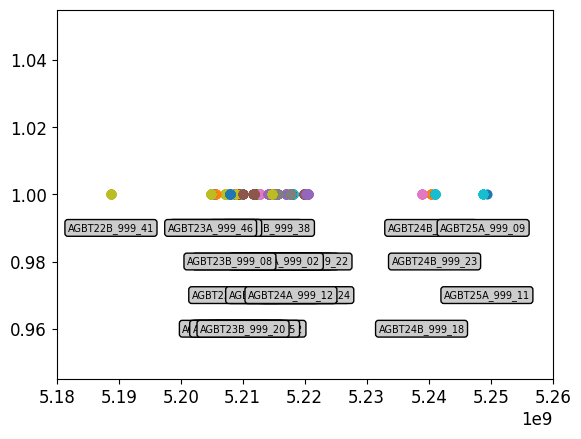

In [8]:
lims = (5.18e9, 5.26e9)
i = 0
for epoch in epochs:
    temp = info[info['epoch'] == epoch]
    times = temp['time'].apply(convert_to_seconds)
    plt.scatter(times, np.ones(len(times)))
    if min(times) > lims[0] and min(times) < lims[1]:
        t = plt.text(min(times), 0.99 - 0.01 * i, epoch, fontsize=7, ha='center', va='center')
        t.set_bbox(dict(boxstyle='round', fc='0.8'))
        i += 1
        if i > 3:
            i -= 4

plt.xlim(lims)

Text(0, 0.5, 'Counts')

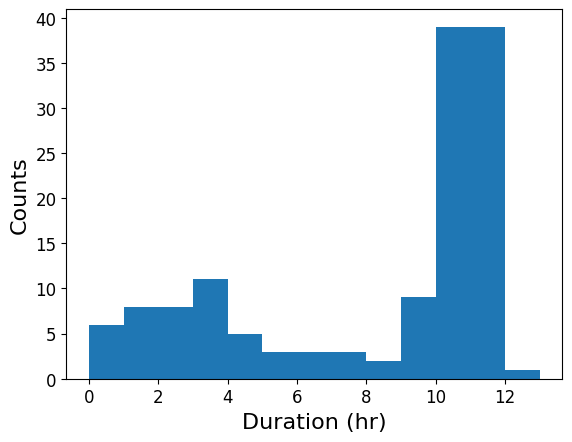

In [9]:
def time_ranges(epochs):
    for epoch in epochs:
        temp = info[info['epoch'] == epoch]
        times = temp['time'].apply(convert_to_seconds)
        yield (max(times) - min(times)) / 3600 #hrs

times = list(time_ranges(epochs))
bin_edges = np.arange(min(times), max(times) + 1)
plt.hist(times, bins=bin_edges)
plt.xlabel('Duration (hr)', fontsize=16)
plt.ylabel('Counts', fontsize=16)

In [10]:
epochs2022 = [epoch for epoch in epochs if 'AGBT22' in epoch]
len(epochs2022)

21

## Spectra in one session

In [11]:
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/preprocessed'

In [12]:
def plot_epoch_spectra(epoch):
    temp = info[info['epoch'] == epoch]
    times = temp['time'].apply(convert_to_seconds)
    times = np.array([time - min(times) for time in times])
    indices = np.argsort(times)
    times = times[indices]
    names = temp['source'].to_numpy()[indices]

    cmap = mpl.colormaps['viridis']
    norm = mpl.colors.Normalize(vmin=min(times), vmax=max(times))

    fig, ax = plt.subplots()
    for name, time in zip(names, times):
        for bank in range(4):
            path = os.path.join(data_dir, str(bank), name + '.npy')
            if os.path.exists(path):
                spec = np.load(path)
                ax.plot(*spec, color=cmap(norm(time)), alpha=0.3)
    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
    cbar.set_label('Time [s]', fontsize=16)

    ax.set_xlabel(r'$\nu$ [MHz]', fontsize=16)
    ax.set_ylabel('Power', fontsize=16)
    ax.set_title(epoch, fontsize=18)

### Pre-2023

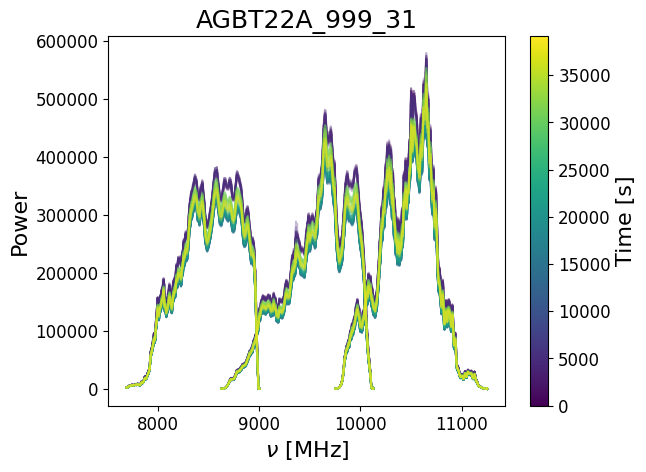

In [13]:
plot_epoch_spectra('AGBT22A_999_31') #'AGBT22A_999_04'

### Post-2023

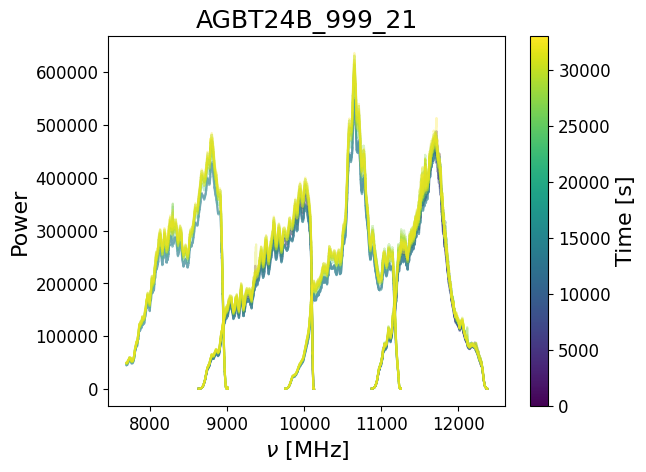

In [14]:
plot_epoch_spectra('AGBT24B_999_21')

# **II. Selecting Calibrators**

In [19]:
calibrator_locs = [loc for loc in locs if '_3C' in loc and get_epoch(loc) in epochs]
calibrator_locs

['/datag/pipeline/AGBT20B_999_49/blc10_blp00/blc10_guppi_59203_24003_3C295_0092.rawspec.0002.h5',
 '/datag/pipeline/AGBT20B_999_49/blc10_blp00/blc10_guppi_59203_23874_3C295_0091.rawspec.0002.h5',
 '/datag/pipeline/AGBT20B_999_49/blc10_blp00/blc10_guppi_59202_85592_3C147_0007.rawspec.0002.h5',
 '/datag/pipeline/AGBT20A_999_44/blc66_blp26/blc66_guppi_59023_23063_3C295_0086.rawspec.0002.h5',
 '/datag/pipeline/AGBT20A_999_44/blc66_blp26/blc66_guppi_59023_23192_3C295_0087.rawspec.0002.h5',
 '/datag/pipeline/AGBT20A_999_44/blc66_blp26/blc66_guppi_59023_00072_3C286_0007.rawspec.0002.h5',
 '/datag/pipeline/AGBT20A_999_44/blc66_blp26/blc66_guppi_59023_00222_3C286_0008.rawspec.0002.h5',
 '/datag/pipeline/AGBT20A_999_44/blc66_blp26/blc66_guppi_59023_00352_3C286_0009.rawspec.0002.h5',
 '/datag/pipeline/AGBT20A_999_44/blc66_blp26/blc66_guppi_59023_02929_3C196_0022.rawspec.0002.h5',
 '/datag/pipeline/AGBT20A_999_44/blc66_blp26/blc66_guppi_59023_03070_3C196_0023.rawspec.0002.h5',
 '/datag/pipeline/AG

In [20]:
calibrator_locs_sorted = {epoch: list(files) for epoch, files in groupby(sorted(calibrator_locs, key=epoch_sort_key), key=get_epoch)}
calibrator_locs_sorted

{'AGBT18B_999_08': ['/datag/pipeline/AGBT18B_999_08/blp11/blc11_guppi_58349_71218_3C286_0007.gpuspec.0002.h5',
  '/datag/pipeline/AGBT18B_999_08/blp03/blc03_guppi_58349_71218_3C286_0007.gpuspec.0002.h5',
  '/datag/pipeline/AGBT18B_999_08/blp21/blc21_guppi_58349_71218_3C286_0007.gpuspec.0002.h5',
  '/datag/pipeline/AGBT18B_999_08/blp05/blc05_guppi_58349_71218_3C286_0007.gpuspec.0002.h5',
  '/datag/pipeline/AGBT18B_999_08/blp13/blc13_guppi_58349_71218_3C286_0007.gpuspec.0002.h5',
  '/datag/pipeline/AGBT18B_999_08/blp00/blc00_guppi_58349_71218_3C286_0007.gpuspec.0002.h5',
  '/datag/pipeline/AGBT18B_999_08/blp15/blc15_guppi_58349_71218_3C286_0007.gpuspec.0002.h5',
  '/datag/pipeline/AGBT18B_999_08/blp26/blc26_guppi_58349_71218_3C286_0007.gpuspec.0002.h5',
  '/datag/pipeline/AGBT18B_999_08/blp22/blc22_guppi_58349_71218_3C286_0007.gpuspec.0002.h5',
  '/datag/pipeline/AGBT18B_999_08/blp16/blc16_guppi_58349_71218_3C286_0007.gpuspec.0002.h5',
  '/datag/pipeline/AGBT18B_999_08/blp06/blc06_guppi_

In [21]:
def group_by_cadence(files): 
    # Remove files without 'blp' - need for splicing
    # files = [f for f in files if 'blp' in f]

    times = sorted(list(set(get_mjd_and_time_seconds(f) for f in files)), key=convert_to_seconds)
    time_vals = [convert_to_seconds(t) for t in times]

    cadences = []
    current_cadence = [times[0]]
    for i in range(len(times)-1):
        diff = int(time_vals[i+1]) - int(time_vals[i])
        if 100 < diff < 140:
            current_cadence.append(times[i+1])
        else:
            cadences.append(current_cadence)
            current_cadence = [times[i+1]]
    cadences.append(current_cadence)
    # Only keep cadences with 3 scans - save just the ON and OFF scans
    if any(len(cadence) > 3 for cadence in cadences):
        print('Warning: Some cadences have more than 3 scans')
    cadences = [cadence for cadence in cadences if len(cadence) >= 3]
    # Create dictionary to store cadences and corresponding files
    # 1/19/26 - doing just the first cadence found, but this might change.
    if len(cadences):
        cadences_dict = {
            'ON': [f for f in files if get_mjd_and_time_seconds(f) == cadences[0][0]],
            'OFF': [f for f in files if get_mjd_and_time_seconds(f) == cadences[0][1]],
        }
        return cadences_dict
    else:
        return None

cadence_group = {
    target: group_by_cadence(files)
    for target, files in calibrator_locs_sorted.items()
    if group_by_cadence(files)
}

cadence_group

{'AGBT19B_999_106': {'ON': ['/datag/pipeline/AGBT19B_999_106/blc41_blp01/blc41_guppi_58798_79789_3C295_0110.gpuspec.0002.h5',
   '/datag/pipeline/AGBT19B_999_106/blc63_blp23/blc63_guppi_58798_79789_3C295_0110.gpuspec.0002.h5',
   '/datag/pipeline/AGBT19B_999_106/blc52_blp12/blc52_guppi_58798_79789_3C295_0110.gpuspec.0002.h5',
   '/datag/pipeline/AGBT19B_999_106/blc46_blp06/blc46_guppi_58798_79789_3C295_0110.gpuspec.0002.h5',
   '/datag/pipeline/AGBT19B_999_106/blc65_blp25/blc65_guppi_58798_79789_3C295_0110.gpuspec.0002.h5',
   '/datag/pipeline/AGBT19B_999_106/blc50_blp10/blc50_guppi_58798_79789_3C295_0110.gpuspec.0002.h5',
   '/datag/pipeline/AGBT19B_999_106/blc61_blp21/blc61_guppi_58798_79789_3C295_0110.gpuspec.0002.h5',
   '/datag/pipeline/AGBT19B_999_106/blc57_blp17/blc57_guppi_58798_79789_3C295_0110.gpuspec.0002.h5',
   '/datag/pipeline/AGBT19B_999_106/blc40_blp00/blc40_guppi_58798_79789_3C295_0110.gpuspec.0002.h5',
   '/datag/pipeline/AGBT19B_999_106/blc54_blp14/blc54_guppi_58798_

In [18]:
len(cadence_group)

46

In [19]:
calibrator_epochs = list(cadence_group.keys())

## Splicing

In [31]:
perley_coeffs = {
    '3C123': [1.8017, -0.7884, -0.1035, -0.0248, 0.0090],
    '3C147': [1.4516, -0.6961, -0.2007, 0.0640, -0.0464, 0.0289],
    '3C196': [1.2872, -0.8530, -0.1534, -0.0200, 0.0201],
    '3C286': [1.2481, -0.4507, -0.1798, 0.0357],
    '3C295': [1.4701, -0.7658, -0.2780, -0.0347, 0.0399],
    '3C48': [1.3253, -0.7553, -0.1914, 0.0498]
}
def flux_jy(freqs, target):
    model = np.poly1d(perley_coeffs[target][::-1])
    return 10**model(np.log10(freqs/1e3)) # convert MHz to GHz

In [ ]:
path_to_save = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_v2/'
rebinned_comb = np.load('/home/dataadmin/GBTData/SharedDataDirectory/rebinned_comb.npy')

def save_bank(items, name=''):
    bank, locs = items
    def despike(ys, cell_size=1024):
        for i in range(cell_size//2-1, len(ys), cell_size):
            ys[i] = np.mean([ys[i-1], ys[i+2]])
            ys[i+1] = np.mean([ys[i], ys[i+2]])
        return ys
    
    def rebin(xs, ys, cell_size=16):
        rebin_size=1024//cell_size
        rebinned_spec = []
        for i in range(len(ys)//rebin_size):
            average = np.mean(ys[i*rebin_size:i*rebin_size+rebin_size])
            rebinned_spec.append(average)

        rebinned_freq = []
        for i in range(len(xs)//rebin_size):
            average = np.mean(xs[i*rebin_size:i*rebin_size+rebin_size])
            rebinned_freq.append(average)
        return rebinned_freq, rebinned_spec
    
    def comb(spec):
        num_windows = len(spec) // 16
        reshaped_power = np.reshape(spec, (num_windows, 16))

        new_power = []
        for i in range(len(reshaped_power)):
            p = reshaped_power[i]
            c = rebinned_comb
            new_power.append(p / c)
        
        return np.concatenate(new_power)

    def process(loc):
        wf = Waterfall(loc)
        xs, ys = wf.grab_data()
        xs = xs[::-1]  # reverse the x-axis
        ys = ys[..., ::-1]  # reverse the y-axis
        ys_avg = np.mean(ys, axis=0)
        ys_despiked = despike(ys_avg)
        xs_rebin, ys_rebin = rebin(xs, ys_despiked)
        ys_combed = comb(ys_rebin)
        rebinned = np.array([xs_rebin, ys_combed])
        return rebinned

    specs = list(map(process, locs))
    bank_spec = np.concatenate(specs, axis=1)
    sort_indices = np.argsort(bank_spec[0])
    bank_spec = bank_spec[:, sort_indices]
    if int(bank) == 0:
        start_freq = 7689.05782699585
        bank_spec = bank_spec[:, np.argmin(np.abs(bank_spec[0] - start_freq)):]
    os.makedirs(os.path.join(path_to_save, bank, name.replace(name.split('/')[-1], '')), exist_ok=True)
    np.save(os.path.join(path_to_save, bank, name), bank_spec)

def splice_banks(name, locs):
    banks = {}
    for loc in locs:
        bank = loc.split('/')[4][-2]
        if bank not in banks:
            banks[bank] = []
        banks[bank].append(loc)
    banks_copy = {}
    for bank in banks.keys():
        new_bank = int(max(banks.keys(), key=int)) - int(bank)
        new_bank = str(new_bank)
        banks_copy[new_bank] = banks[bank]
    banks = banks_copy

    save_bank_partial = partial(save_bank, name=name)
    _ = list(map(save_bank_partial, banks.items()))
    gc.collect()
    return list(banks.keys())

def save_cadence(items):
    epoch, cadence_dict = items
    name_on = f'{epoch}/ON.npy'
    banks_on = splice_banks(name_on, cadence_dict['ON'])
    name_off = f'{epoch}/OFF.npy'
    banks_off = splice_banks(name_off, cadence_dict['OFF'])
    banks = set(banks_on).intersection(set(banks_off))

    for bank in banks:
        bank_path = os.path.join(path_to_save, bank)
        spec_on = np.load(os.path.join(bank_path, name_on))
        spec_off = np.load(os.path.join(bank_path, name_off))
        spec_diff = np.array([spec_on[0], spec_on[1] - spec_off[1]])
        
        target = cadence_dict['ON'][0].split('/')[5].split('_')[4]
        s_cal = flux_jy(spec_on[0], target)
        spec_gain = np.array([spec_on[0], spec_diff[1] / s_cal])

        np.save(os.path.join(bank_path, f'{epoch}/ON_OFF.npy'), spec_diff)
        np.save(os.path.join(bank_path, f'{epoch}/gain.npy'), spec_gain)

_ = list(tqdm(map(save_cadence, cadence_group.items()), total=len(cadence_group)))

In [ ]:
calibration_path = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_v2/'

bad_epochs = []

for epoch in cadence_group.keys():
    for bank in range(3):
        shape = 7168 if bank == 0 else 8192
        calibration_dir = os.path.join(calibration_path, str(bank), epoch)
        gain_path = os.path.join(calibration_dir, 'gain.npy')
        gain = np.load(gain_path)
        if gain.shape[1] != shape and epoch not in bad_epochs:
            print(f'SEFD shape mismatch for {bank}/{epoch}')
            bad_epochs.append(epoch)

print(bad_epochs)

In [ ]:
for epoch in bad_epochs:
    calibrator_epochs.remove(epoch)
    for bank in range(3):
        shutil.rmtree(os.path.join(calibration_path, str(bank), epoch), ignore_errors=True)

In [ ]:
banks = os.listdir(calibration_path)
for bank in banks:
    if int(bank) > 2:
        shutil.rmtree(os.path.join(calibration_path, str(bank)), ignore_errors=True)

In [ ]:
'AGBT21A_996_36' in calibrator_epochs

## Plotting

In [ ]:
time_lookup = {
    epoch: convert_to_seconds(get_mjd_and_time_seconds(epoch_dict['ON'][0]))
    for epoch, epoch_dict in cadence_group.items()
}
time_lookup

In [ ]:
# Plot gains over time
calibration_path = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_v2/'

all_gains = []
epochs_lst = []

for epoch in calibrator_epochs:
    for bank in range(3):
        shape = 7168 if bank == 0 else 8192
        calibration_dir = os.path.join(calibration_path, str(bank), epoch)
        if not os.path.exists(calibration_dir):
            print(f'No data for {epoch} in bank {bank}, skipping')
            continue
        gain_path = os.path.join(calibration_dir, 'gain.npy')
        try:
            gain = np.load(gain_path)
            if gain.shape[1] != shape:
                print(f'SEFD shape mismatch for {bank}/{epoch}, skipping')
                print(gain.shape)
                continue
            norm_gain = gain[1] / np.median(gain[1])
            all_gains.append(np.array([gain[0], norm_gain]))
            epochs_lst.append(epoch)
        except Exception as e:
            print(f'Error processing {bank}/{epoch}: {e}, skipping')
            continue

cmap = mpl.colormaps['viridis']
times = time_lookup.values()
norm = mpl.colors.Normalize(vmin=min(times), vmax=max(times))

fig, ax = plt.subplots(figsize=(20, 6))
for epoch, gain in zip(epochs_lst, all_gains):
    ax.plot(gain[0], gain[1], alpha=0.5, color=cmap(norm(time_lookup[epoch])))
ax.set_xlabel('$\\nu$ [MHz]', fontsize=16)
ax.set_ylabel('Median-Normalized Gain', fontsize=16)
ax.set_ylim(0, 5)
cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label('Time (s since MJD 0)', fontsize=16)

import matplotlib.ticker as tck
ax.xaxis.set_minor_locator(tck.MultipleLocator(100))

In [ ]:
plt.plot(*np.load('/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_v2/0/AGBT24A_999_24/gain.npy'))

# **III. Gain Correction**

In [16]:
calibrator_epochs = os.listdir('/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_v2/0')

In [18]:
info_trimmed = info[info['epoch'].isin(calibrator_epochs)]
info_trimmed

,source,epoch,time,ra,dec,l,b,theta,phi,nfw,nfw_sq,iso,iso_sq,burkert,burkert_sq,moore,moore_sq
1,HIP38468,AGBT20B_999_54,59214_38477,118.1838,12.0399,208.821296,18.974616,117.121857,145.947125,1.058735e+08,5.479899e+14,2.602043e+08,1.212893e+15,9.089486e+07,4.472811e+14,2.322709e+07,3.181333e+13
2,HIP116538,AGBT20B_999_49,59203_03185,354.3079,57.9490,113.193170,-3.512770,23.443145,113.147054,1.279805e+08,7.541369e+14,2.869724e+08,1.465254e+15,1.107629e+08,6.130784e+14,2.865754e+07,4.469731e+13
3,HIP96264,AGBT20B_999_49,59203_36476,293.5826,71.6109,103.349354,22.362166,25.866928,102.328982,1.403981e+08,8.868837e+14,3.001235e+08,1.599971e+15,1.218205e+08,7.177445e+14,3.177227e+07,5.320469e+13
58,HIP82993,AGBT20B_999_11,59096_42156,254.4623,80.2159,112.843355,31.418078,38.144553,109.347439,1.319729e+08,7.954404e+14,2.913366e+08,1.509159e+15,1.143286e+08,6.458359e+14,2.965406e+07,4.732759e+13
59,HIP82871,AGBT20B_999_11,59096_43440,254.0654,77.6574,110.101027,32.484857,37.612905,106.852127,1.348043e+08,8.255182e+14,2.943523e+08,1.539961e+15,1.168517e+08,6.695834e+14,3.036365e+07,4.925264e+13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,HIP6529,AGBT20B_996_01,59225_75932,20.9600,25.9246,131.988102,-36.376712,53.241482,122.589484,1.195448e+08,6.710386e+14,2.772991e+08,1.370729e+15,1.032019e+08,5.466822e+14,2.656755e+07,3.945346e+13
4995,HIP5701,AGBT20B_996_01,59225_76780,18.3398,25.4659,129.141570,-37.141396,51.810902,120.211314,1.214849e+08,6.896553e+14,2.795800e+08,1.392673e+15,1.049437e+08,5.616120e+14,2.704631e+07,4.062254e+13
4996,HIP5777,AGBT20B_996_01,59225_78072,18.5185,25.8356,129.291960,-36.756451,51.679375,120.488749,1.212525e+08,6.874098e+14,2.793086e+08,1.390051e+15,1.047351e+08,5.598128e+14,2.698890e+07,4.048135e+13
4997,HIP5965,AGBT20B_996_01,59225_77421,19.1727,24.5039,130.227874,-38.009838,53.018922,120.587397,1.211702e+08,6.866161e+14,2.792124e+08,1.389122e+15,1.046613e+08,5.591768e+14,2.696859e+07,4.043146e+13


In [37]:
names_trimmed = info_trimmed['source']

In [38]:
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/preprocessed'
calibration_path = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_v2/'
path_to_save = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/calibrated'

for name in tqdm(names_trimmed):
    epoch = info_trimmed.loc[info_trimmed['source'] == name, 'epoch'].iloc[0]
    for bank in range(3):
        data_path = os.path.join(data_dir, str(bank), name + '.npy')
        gain_path = os.path.join(calibration_path, str(bank), epoch, 'gain.npy')
        
        if os.path.exists(data_path):
            data = np.load(data_path)
            gain = np.load(gain_path)
            data_cal = data[1] / gain[1]
            save = np.array([data[0], data_cal])

            save_dir = os.path.join(path_to_save, str(bank))
            os.makedirs(save_dir, exist_ok=True)
            np.save(os.path.join(save_dir, name), save)

  0%|          | 2/1979 [00:00<02:22, 13.92it/s]

100%|██████████| 1979/1979 [01:24<00:00, 23.52it/s]


In [20]:
[len(os.listdir(os.path.join(path_to_save, str(bank)))) for bank in range(3)]

[1927, 1892, 1889]

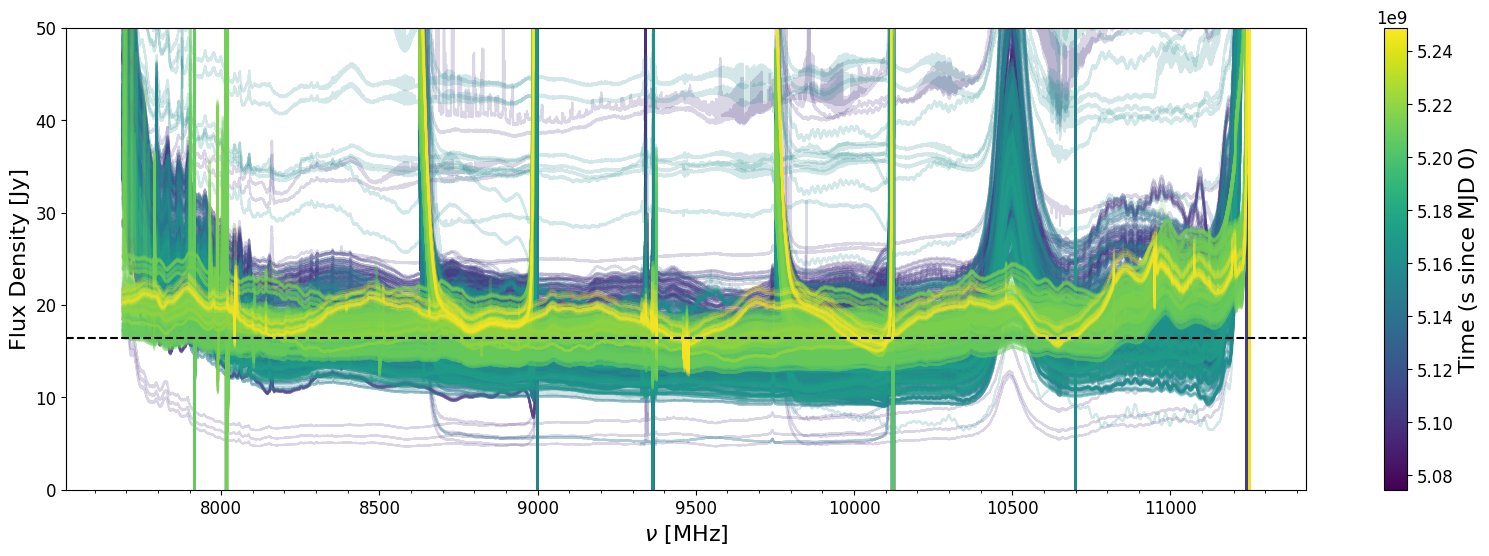

In [44]:
# Plot calibrated spectra over time
all_spectra = []
times = []

for name in names_trimmed:
    time = convert_to_seconds(info_trimmed.loc[info_trimmed['source'] == name, 'time'].iloc[0])
    for bank in range(3):
        data_path = os.path.join(path_to_save, str(bank), name + '.npy')
        if os.path.exists(data_path):
            data = np.load(data_path)
            all_spectra.append(np.array(data))
            times.append(time)

cmap = mpl.colormaps['viridis']
combined = sorted(zip(times, all_spectra), key=lambda x: x[0])

norm = mpl.colors.Normalize(vmin=min(times), vmax=max(times))

fig, ax = plt.subplots(figsize=(20, 6))
for time, spec in combined:
    ax.plot(spec[0], spec[1], alpha=0.2, color=cmap(norm(time)))
ax.set_xlabel('$\\nu$ [MHz]', fontsize=16)
ax.set_ylabel('Flux Density [Jy]', fontsize=16)
cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label('Time (s since MJD 0)', fontsize=16)

ax.set_ylim(0, 50)

k = 1.38e-23  # Boltzmann constant in J/K
JY_PER_J = 1e26 # Jy per Joule

a_eff = 0.7 * np.pi * 50**2
Tsky = 2.728
sky = 2 * k * JY_PER_J * Tsky / a_eff

ax.axhline(15 + sky, color='k', linestyle='--', label='GBT Manual estimate')

import matplotlib.ticker as tck
ax.xaxis.set_minor_locator(tck.MultipleLocator(100))

## Calibrated spectra by session

In [54]:
def plot_epoch_calibrated_spectra(epoch):
    data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/calibrated'

    temp = info[info['epoch'] == epoch]
    times = temp['time'].apply(convert_to_seconds)
    times = np.array([time - min(times) for time in times])
    indices = np.argsort(times)
    times = times[indices]
    names = temp['source'].to_numpy()[indices]

    cmap = mpl.colormaps['viridis']
    norm = mpl.colors.Normalize(vmin=min(times), vmax=max(times))

    fig, ax = plt.subplots(figsize=(15,6))
    ypbots = []
    yptops = []
    for name, time in zip(names, times):
        for bank in range(3):
            path = os.path.join(data_dir, str(bank), name + '.npy')
            if os.path.exists(path):
                spec = np.load(path)
                ax.plot(*spec, color=cmap(norm(time)), alpha=0.3, rasterized=True)
                ypbots.append(np.percentile(spec[1], 5))
                yptops.append(np.percentile(spec[1], 95))
    
    ypbot = np.percentile(ypbots, 5)
    yptop = np.percentile(yptops, 95)
    ypad = 0.1 * (yptop - ypbot)

    ax.set_ylim(ypbot-ypad, yptop+ypad)

    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
    cbar.set_label('Time [s]', fontsize=16)

    ax.set_xlabel(r'$\nu$ [MHz]', fontsize=16)
    ax.set_ylabel('$S$ [Jy]', fontsize=16)
    ax.set_title(epoch, fontsize=18)

    ax.xaxis.set_minor_locator(tck.MultipleLocator(100))

    return fig

plt.rcParams['path.simplify'] = True
plt.rcParams['path.simplify_threshold'] = 0.5

from matplotlib.backends.backend_pdf import PdfPages

pdf = PdfPages('/home/dataadmin/GBTData/SharedDataDirectory/calibrated_spectra.pdf')

for epoch in calibrator_epochs:
    fig = plot_epoch_calibrated_spectra(epoch)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

pdf.close()

In [24]:
#diffs
def plot_epoch_calibrated_spectra_diffs(epoch):
    data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/calibrated'

    temp = info[info['epoch'] == epoch]
    times = temp['time'].apply(convert_to_seconds)
    times = np.array([time - min(times) for time in times])
    indices = np.argsort(times)
    times = times[indices]
    names = temp['source'].to_numpy()[indices]

    cmap = mpl.colormaps['viridis']
    norm = mpl.colors.Normalize(vmin=min(times), vmax=max(times))

    fig, ax = plt.subplots(figsize=(15,6))
    ypbots = []
    yptops = []
    for i in range(len(times)-1):
        for bank in range(3):
            path1 = os.path.join(data_dir, str(bank), names[i] + '.npy')
            path2 = os.path.join(data_dir, str(bank), names[i+1] + '.npy')
            if os.path.exists(path1) and os.path.exists(path2):
                spec1 = np.load(path1)
                spec2 = np.load(path2)
                diff = spec2[1] - spec1[1]
                ax.plot(spec1[0], diff, color=cmap(norm(times[i])), alpha=0.3, rasterized=True)
                ypbots.append(np.percentile(diff, 1))
                yptops.append(np.percentile(diff, 99))
    
    ypbot = np.percentile(ypbots, 5)
    yptop = np.percentile(yptops, 95)
    ypad = 0.1 * (yptop - ypbot)

    ax.set_ylim(ypbot-ypad, yptop+ypad)

    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
    cbar.set_label('Time [s]', fontsize=16)

    ax.set_xlabel(r'$\nu$ [MHz]', fontsize=16)
    ax.set_ylabel('$\Delta S$ [Jy]', fontsize=16)
    ax.set_title(epoch, fontsize=18)

    ax.xaxis.set_minor_locator(tck.MultipleLocator(100))

    return fig

plt.rcParams['path.simplify'] = True
plt.rcParams['path.simplify_threshold'] = 0.5

from matplotlib.backends.backend_pdf import PdfPages

pdf = PdfPages('/home/dataadmin/GBTData/SharedDataDirectory/calibrated_spectra_diffs.pdf')

for epoch in calibrator_epochs:
    fig = plot_epoch_calibrated_spectra_diffs(epoch)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

pdf.close()

# **IV. Normalization (1e-29 decay, 9200 MHz)** 

In [10]:
c = 299792
v_virial = 250 # km/s
v_earth  = 225 # km/s
v_virial*9200/(c*np.sqrt(3)) / 0.18 * 16

393.7265004880834

In [11]:
os.chdir('/home/bhanselman-test/bhanselman/scripts')

In [12]:
from normalization_methods import *

freq = 9200
signal_size = 1e-29

In [13]:
def sigma_filter(data, window_size=15):
    for i in range(window_size//2, len(data)-window_size//2):
        window_data = data[i-window_size//2:i+window_size//2+1]
        median = np.median(window_data)
        std = np.std(window_data)
        if abs(data[i] - median) > 3 * std:
            data[i] = median
    return data

def build_asymmetry_modified(data_dir, angle, lower, upper, spectra=None):
    if spectra is None:
        spectra = os.listdir(data_dir)
    
    inner_pre = info[(info[angle] < lower) & (info['time'].apply(lambda t: convert_to_seconds(t) < 5.18e9))]
    inner_post = info[(info[angle] < lower) & (info['time'].apply(lambda t: convert_to_seconds(t) >= 5.18e9))]
    outer_pre = info[(info[angle] > upper) & (info['time'].apply(lambda t: convert_to_seconds(t) < 5.18e9))]
    outer_post = info[(info[angle] > upper) & (info['time'].apply(lambda t: convert_to_seconds(t) >= 5.18e9))]

    inner_pre_spectra = [np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in inner_pre['source'].tolist()]
    inner_post_spectra = [np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in inner_post['source'].tolist()]
    outer_pre_spectra = [np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in outer_pre['source'].tolist()]
    outer_post_spectra = [np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in outer_post['source'].tolist()]

    inner_pre_mean = np.mean(inner_pre_spectra, axis=0)
    inner_post_mean = np.mean(inner_post_spectra, axis=0)
    outer_pre_mean = np.mean(outer_pre_spectra, axis=0)
    outer_post_mean = np.mean(outer_post_spectra, axis=0)

    asymmetry = (inner_pre_mean + inner_post_mean - outer_pre_mean - outer_post_mean) / (inner_pre_mean + inner_post_mean + outer_pre_mean + outer_post_mean)
    xs = np.load(os.path.join(data_dir, spectra[0]))[0]
    asymmetry = sigma_filter(asymmetry)
    return xs, asymmetry

100%|██████████| 4653/4653 [08:16<00:00,  9.37it/s]


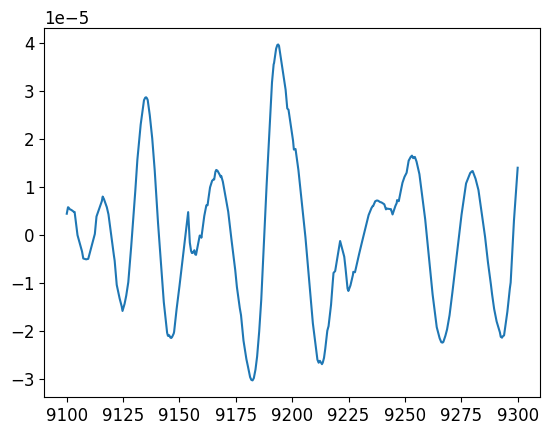

In [39]:
# Old method - using "preprocessed" spectra
uninjected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/preprocessed/1'
injected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/old/injected'
normalized_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/old/normalized'
calibration_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/median_sefds/1'

os.makedirs(injected_dir, exist_ok=True)
os.makedirs(normalized_dir, exist_ok=True)

def normalize(targ):
    inject_calibrated(
        targ,
        freq,
        info,
        data_dir=uninjected_dir,
        save_dir=injected_dir,
        calibration_dir=calibration_dir,
        signal_sizes=signal_size,
    )
    normalize_weighted(
        targ,
        data_dir=injected_dir,
        save_dir=normalized_dir,
        exterior=8,
        freq=9200,
        width=100
    )

with Pool(processes=10) as p:
    _ = list(tqdm(p.imap_unordered(normalize, os.listdir(uninjected_dir)), total=len(os.listdir(uninjected_dir))))

xs, asymmetry = build_asymmetry_modified(normalized_dir, 'phi', 70, 115)
plt.plot(xs, asymmetry)

100%|██████████| 1892/1892 [03:58<00:00,  7.92it/s]


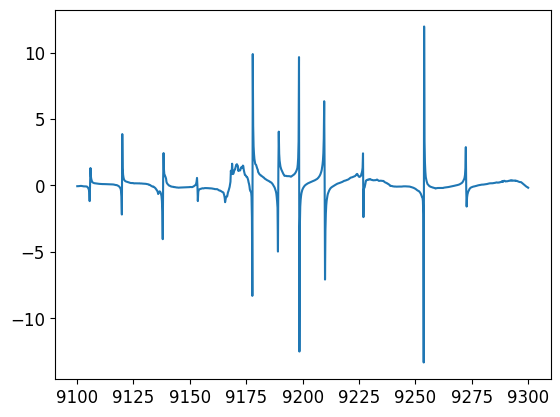

In [24]:
# New method - using "calibrated" spectra
uninjected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/calibrated/1'
injected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/new/injected'
normalized_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/new/normalized'

os.makedirs(injected_dir, exist_ok=True)
os.makedirs(normalized_dir, exist_ok=True)

def normalize(targ):
    inject_calibrated_v2(
        targ,
        freq,
        info,
        data_dir=uninjected_dir,
        save_dir=injected_dir,
        signal_sizes=signal_size,
    )
    normalize_weighted_v2(
        targ,
        data_dir=injected_dir,
        save_dir=normalized_dir,
        exterior=8,
        freq=9200,
        width=100
    )

with Pool(processes=10) as p:
    _ = list(tqdm(p.imap_unordered(normalize, os.listdir(uninjected_dir)), total=len(os.listdir(uninjected_dir))))

xs, asymmetry = build_asymmetry_modified(normalized_dir, 'phi', 70, 115)
plt.plot(xs, asymmetry)

In [52]:
normalized_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/new/normalized'

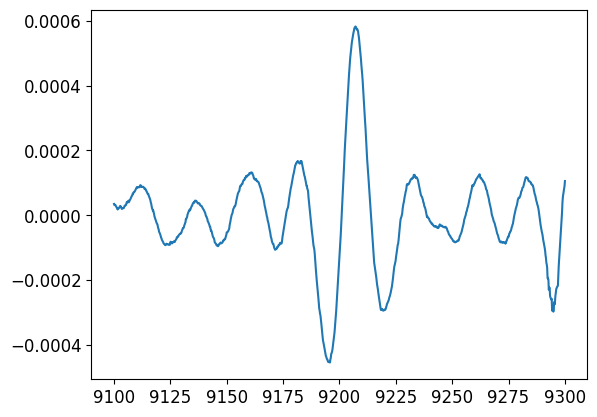

In [53]:
def build_asymmetry_modified_v2(data_dir, angle, lower, upper, spectra=None):
    if spectra is None:
        spectra = os.listdir(data_dir)
    
    inner_pre = info[(info[angle] < lower) & (info['time'].apply(lambda t: convert_to_seconds(t) < 5.18e9))]
    inner_post = info[(info[angle] < lower) & (info['time'].apply(lambda t: convert_to_seconds(t) >= 5.18e9))]
    outer_pre = info[(info[angle] > upper) & (info['time'].apply(lambda t: convert_to_seconds(t) < 5.18e9))]
    outer_post = info[(info[angle] > upper) & (info['time'].apply(lambda t: convert_to_seconds(t) >= 5.18e9))]

    inner_pre_spectra = [np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in inner_pre['source'].tolist()]
    inner_post_spectra = [np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in inner_post['source'].tolist()]
    outer_pre_spectra = [np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in outer_pre['source'].tolist()]
    outer_post_spectra = [np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in outer_post['source'].tolist()]

    inner_pre_mean = np.mean(inner_pre_spectra, axis=0)
    inner_post_mean = np.mean(inner_post_spectra, axis=0)
    outer_pre_mean = np.mean(outer_pre_spectra, axis=0)
    outer_post_mean = np.mean(outer_post_spectra, axis=0)

    asymmetry = (inner_pre_mean + inner_post_mean - outer_pre_mean - outer_post_mean) / (inner_pre_mean + inner_post_mean + outer_pre_mean + outer_post_mean + 4)
    xs = np.load(os.path.join(data_dir, spectra[0]))[0]
    asymmetry = sigma_filter(asymmetry)
    return xs, asymmetry

xs, asymmetry = build_asymmetry_modified_v2(normalized_dir, 'phi', 70, 115)
plt.plot(xs, asymmetry)

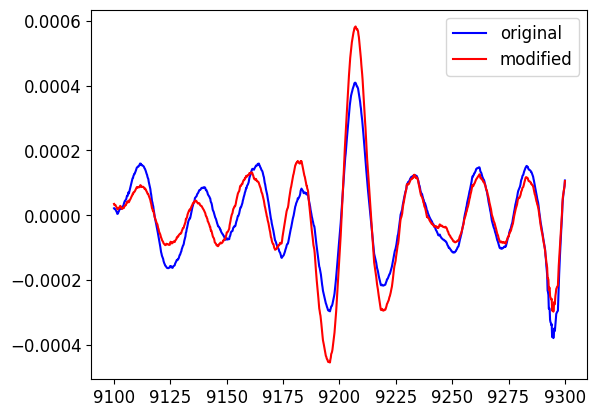

In [20]:
def build_asymmetry_v2(data_dir, angle, lower, upper):
    spectra = os.listdir(data_dir)
    inner = info[info[angle] < lower]
    outer = info[info[angle] > upper]
    inner_spectra = np.array([np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in inner['source'].tolist()])
    outer_spectra = np.array([np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in outer['source'].tolist()])
    inner_mean = np.mean(inner_spectra, axis=0)
    outer_mean = np.mean(outer_spectra, axis=0)
    asymmetry = (inner_mean - outer_mean) / (inner_mean + outer_mean + 2)
    xs = np.load(os.path.join(data_dir, spectra[0]))[0]
    return xs, asymmetry

xs, asymmetry = build_asymmetry_v2(normalized_dir, 'phi', 70, 115)
xs, asymmetry_mod = build_asymmetry_modified_v2(normalized_dir, 'phi', 70, 115)

plt.plot(xs, asymmetry, c='b', label='original')
plt.plot(xs, asymmetry_mod, c='r', label='modified')
plt.legend()

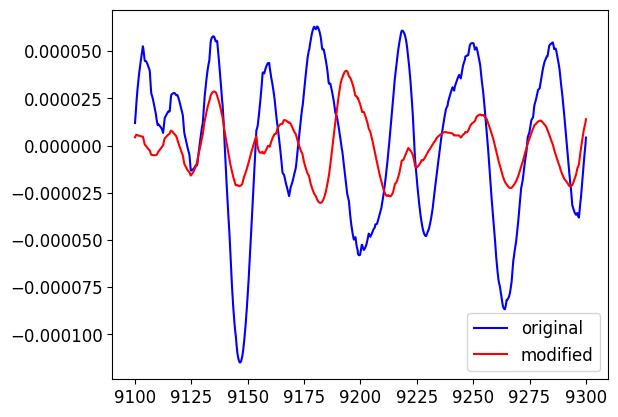

In [34]:
# Same comparison, but old
def build_asymmetry(data_dir, angle, lower, upper):
    spectra = os.listdir(data_dir)
    inner = info[info[angle] < lower]
    outer = info[info[angle] > upper]
    inner_spectra = np.array([np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in inner['source'].tolist()])
    outer_spectra = np.array([np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in outer['source'].tolist()])
    inner_mean = np.mean(inner_spectra, axis=0)
    outer_mean = np.mean(outer_spectra, axis=0)
    asymmetry = (inner_mean - outer_mean) / (inner_mean + outer_mean)
    xs = np.load(os.path.join(data_dir, spectra[0]))[0]
    return xs, asymmetry

normalized_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/old/normalized'
xs, asymmetry = build_asymmetry(normalized_dir, 'phi', 70, 115)
xs, asymmetry_mod = build_asymmetry_modified(normalized_dir, 'phi', 70, 115)

plt.plot(xs, asymmetry, c='b', label='original')
plt.plot(xs, asymmetry_mod, c='r', label='modified')
plt.legend()

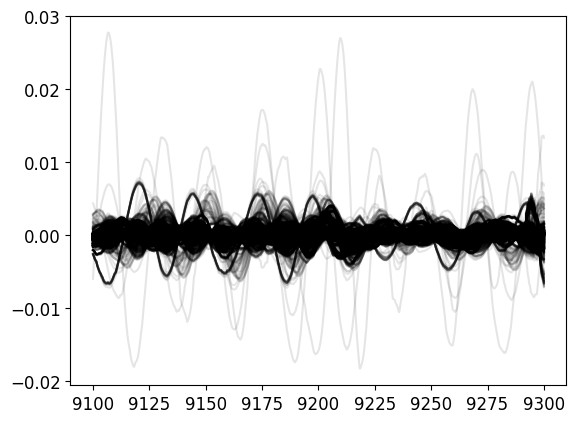

In [25]:
# Plot normalized spectra - new
normalized_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/new/normalized'
for targ in os.listdir(normalized_dir):
    plt.plot(*np.load(os.path.join(normalized_dir, targ)), c='k', alpha=0.1)

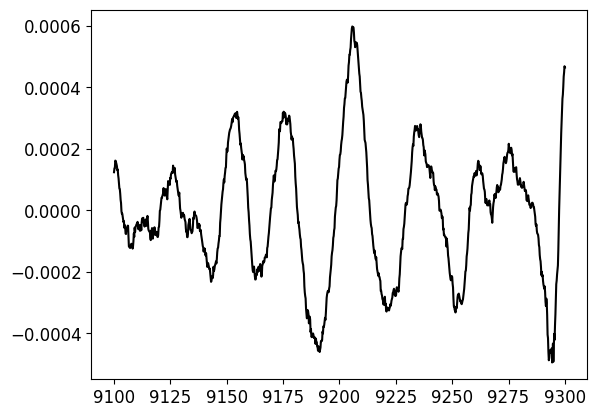

In [26]:
# A typical normalized spectrum
targ = 'HIP5526.npy' #random.choice(os.listdir(normalized_dir))
plt.plot(*np.load(os.path.join(normalized_dir, targ)), c='k')

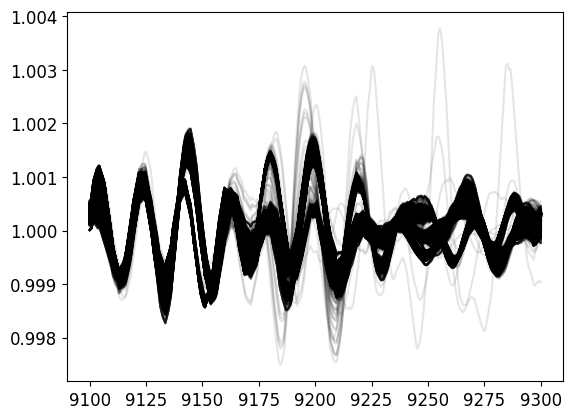

In [46]:
# Plot normalized spectra - old
normalized_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/old/normalized'
for targ in os.listdir(normalized_dir):
    plt.plot(*np.load(os.path.join(normalized_dir, targ)), c='k', alpha=0.1)

Text(0.5, 1.0, 'HIP5526.npy')

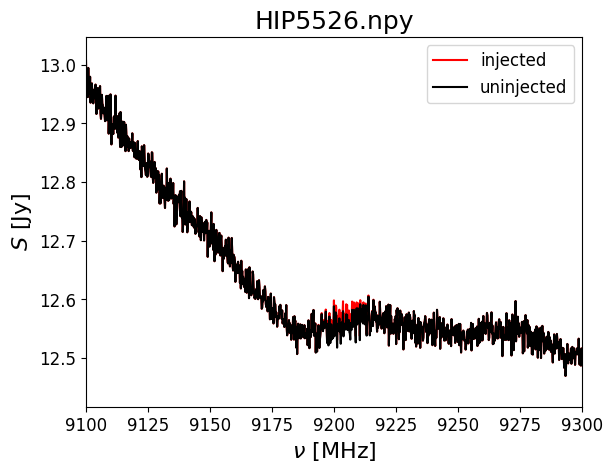

In [25]:
# A raw calibrated spectrum, before and after injection
uninjected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/calibrated/1'
injected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/new/injected'
targ = 'HIP5526.npy' #random.choice(os.listdir(uninjected_dir))

inj = np.load(os.path.join(injected_dir, targ))
uninj = np.load(os.path.join(uninjected_dir, targ))
plt.plot(*inj, c='r', label='injected')
plt.plot(*uninj, c='k', label='uninjected')
plt.xlim(9100, 9300)

ymin = np.min(inj[1][np.argmin(np.abs(inj[0]-9100)):np.argmin(np.abs(inj[0]-9300))])
ymax = np.max(inj[1][np.argmin(np.abs(inj[0]-9100)):np.argmin(np.abs(inj[0]-9300))])
ypad = 0.1 * (ymax - ymin)
plt.ylim(ymin-ypad, ymax+ypad)

plt.legend()
plt.xlabel(r'$\nu$ [MHz]', fontsize=16)
plt.ylabel('$S$ [Jy]', fontsize=16)
plt.title(targ, fontsize=18)


In [26]:
inj.shape

(2, 8192)

In [72]:
info[info['source'] == targ.replace('.npy', '')]['epoch']

4990    AGBT20B_996_01
Name: epoch, dtype: object

Text(0.5, 1.0, 'HIP5526.npy')

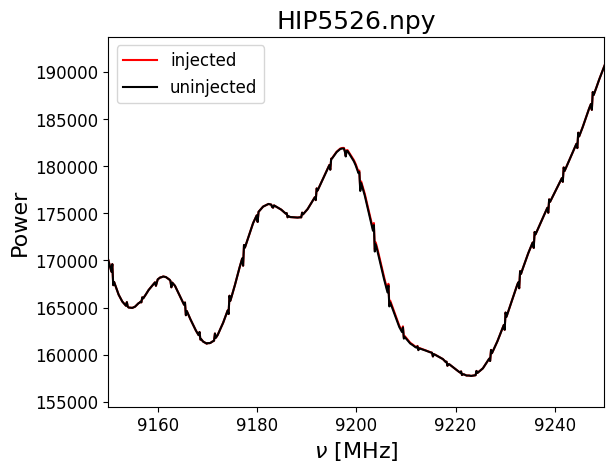

In [80]:
# Same object, both with uncalibrated spectra
uninjected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/preprocessed/1'
injected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/old/injected'
targ = 'HIP5526.npy' #random.choice(os.listdir(uninjected_dir))

inj = np.load(os.path.join(injected_dir, targ))
uninj = np.load(os.path.join(uninjected_dir, targ))
plt.plot(*inj, c='r', label='injected')
plt.plot(*uninj, c='k', label='uninjected')
plt.xlim(9150, 9250)

ymin = np.min(inj[1][np.argmin(np.abs(inj[0]-9150)):np.argmin(np.abs(inj[0]-9250))])
ymax = np.max(inj[1][np.argmin(np.abs(inj[0]-9150)):np.argmin(np.abs(inj[0]-9250))])
ypad = 0.1 * (ymax - ymin)
plt.ylim(ymin-ypad, ymax+ypad)

plt.legend()
plt.xlabel(r'$\nu$ [MHz]', fontsize=16)
plt.ylabel('Power', fontsize=16)
plt.title(targ, fontsize=18)

## New normalized spectra by session

In [84]:
def plot_epoch_normalized_spectra(epoch):
    data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/new/normalized'

    temp = info[info['epoch'] == epoch]
    times = temp['time'].apply(convert_to_seconds)
    times = np.array([time - min(times) for time in times])
    indices = np.argsort(times)
    times = times[indices]
    names = temp['source'].to_numpy()[indices]

    cmap = mpl.colormaps['viridis']
    norm = mpl.colors.Normalize(vmin=min(times), vmax=max(times))

    fig, ax = plt.subplots(figsize=(15,6))
    ypbots = []
    yptops = []
    for name, time in zip(names, times):
        path = os.path.join(data_dir, name + '.npy')
        if os.path.exists(path):
            spec = np.load(path)
            ax.plot(*spec, color=cmap(norm(time)), alpha=0.3, rasterized=True)
            ypbots.append(np.percentile(spec[1], 0))
            yptops.append(np.percentile(spec[1], 100))
    
    ypbot = np.percentile(ypbots, 0)
    yptop = np.percentile(yptops, 100)
    ypad = 0.1 * (yptop - ypbot)

    ax.set_xlim(min(spec[0]), max(spec[0]))
    ax.set_ylim(ypbot-ypad, yptop+ypad)

    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
    cbar.set_label('Time [s]', fontsize=16)

    ax.set_xlabel(r'$\nu$ [MHz]', fontsize=16)
    ax.set_ylabel('Normalized Flux Density [Jy]', fontsize=16)
    ax.set_title(epoch, fontsize=18)

    ax.xaxis.set_minor_locator(tck.MultipleLocator(100))

    return fig

plt.rcParams['path.simplify'] = True
plt.rcParams['path.simplify_threshold'] = 0.5

from matplotlib.backends.backend_pdf import PdfPages

pdf = PdfPages('/home/dataadmin/GBTData/SharedDataDirectory/normalized_spectra.pdf')

for epoch in calibrator_epochs:
    fig = plot_epoch_normalized_spectra(epoch)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

pdf.close()

## Different window size?

100%|██████████| 1892/1892 [03:28<00:00,  9.08it/s]


(9175.0, 9225.0)

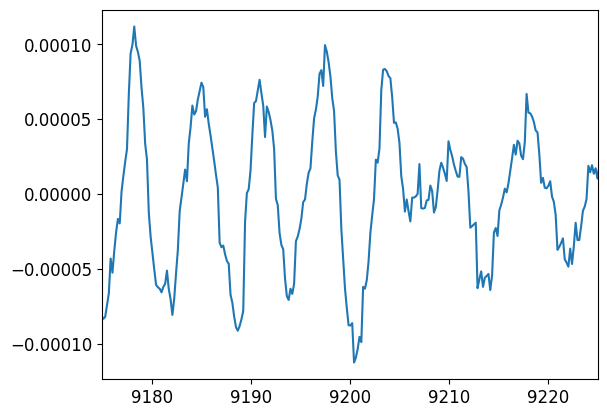

In [32]:
new_uninjected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/calibrated/1'
new_uninj_normalized_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/new_b_0.25/normalized_uninjected'

def normalize_new(targ):
    normalize_weighted_v2(
        targ,
        data_dir=new_uninjected_dir,
        save_dir=new_uninj_normalized_dir,
        exterior=2,
        freq=9200,
        width=100,
        b=0.25
    )

with Pool(processes=10) as p:
    _ = list(tqdm(p.imap_unordered(normalize_new, os.listdir(new_uninjected_dir)), total=len(os.listdir(new_uninjected_dir))))

xs, asymmetry = build_asymmetry_modified_v2(new_uninj_normalized_dir, 'phi', 70, 115)
plt.plot(xs, asymmetry)
plt.xlim(9175, 9225)

### For exterior = 2, b = 0.25 (searching for 1/4 of the signal width), periodicity does not go away. Appears noisier bc the period is smaller, closer to the scale of noise variation

### What about a smaller window size but the same signal width

In [115]:
new_uninjected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/calibrated/1'
new_uninj_normalized_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/new_exterior_4/normalized_uninjected'

  0%|          | 0/1892 [00:00<?, ?it/s]

100%|██████████| 1892/1892 [03:42<00:00,  8.51it/s]


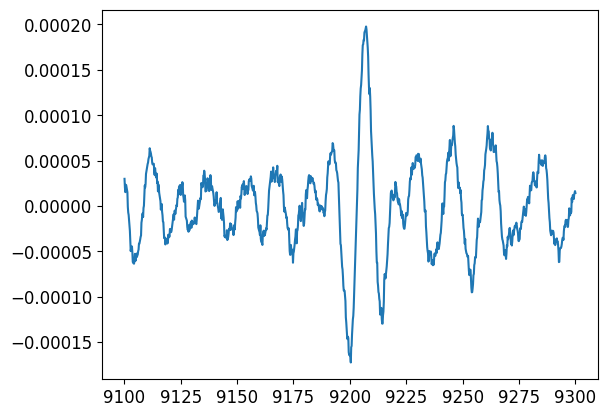

In [ ]:
def normalize_new(targ):
    normalize_weighted_v2(
        targ,
        data_dir=new_uninjected_dir,
        save_dir=new_uninj_normalized_dir,
        exterior=4,
        freq=9200,
        width=100,
        b=1
    )

with Pool(processes=10) as p:
    _ = list(tqdm(p.imap_unordered(normalize_new, os.listdir(new_uninjected_dir)), total=len(os.listdir(new_uninjected_dir))))

xs, asymmetry = build_asymmetry_modified_v2(new_uninj_normalized_dir, 'phi', 70, 115)
plt.plot(xs, asymmetry)

HUH?!

In [31]:
def plot_heatmaps(info, data_dir, freq=None, n_time_bins=50, n_bins=50):
    info['time_mjd'] = [int(mjd.split('_')[0]) for mjd in info['time']]
    info['cos_theta'] = [math.cos(math.radians(theta)) for theta in info['theta']]
    info['cos_phi'] = [math.cos(math.radians(phi)) for phi in info['phi']]
    
    time_bins = np.linspace(min(info['time_mjd']), max(info['time_mjd']), n_time_bins+1)
    bins = np.linspace(-1, 1, n_bins+1)
    info['time_mjd_bin'] = pd.cut(info['time_mjd'], time_bins, labels=False)
    info['cos_theta_bin'] = pd.cut(info['cos_theta'], bins, labels=False)
    info['cos_phi_bin'] = pd.cut(info['cos_phi'], bins, labels=False)
    
    normalized_spectra = [np.load(os.path.join(data_dir, file)) for file in os.listdir(data_dir)]
    xs = normalized_spectra[0][0]
    if freq:
        mask = (xs >= freq-50) & (xs < freq+50)
    else:
        mask = np.full(xs.shape, True)

    nans = np.full(xs.shape, np.nan)[mask]

    def create_map(bin_column, n_bins_):
        for i in range(n_bins_):
            sources = info[info[bin_column] == i]['source'].tolist()
            spectra = np.array([np.load(os.path.join(data_dir, file))[1][mask] for file in os.listdir(data_dir) if file[:-4] in sources])
            if spectra.size:
                avg = np.mean(spectra, axis=0)
                yield avg
            else:
                yield nans
    
    time_map = list(create_map('time_mjd_bin', n_time_bins))
    theta_map = list(create_map('cos_theta_bin', n_bins))
    phi_map = list(create_map('cos_phi_bin', n_bins))
    
    fig = plt.figure(figsize=(18, 18))
    axs = fig.subplots(3, 1)

    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(np.array(theta_map))
    print(vmin, vmax)
    vmax = max(vmax, -vmin)
    print(vmax)
    ndigits = -int(math.floor(math.log10(vmax))) + 1
    vmax = round(vmax, ndigits)
    norm = Normalize(vmin=-vmax, vmax=vmax)
    extent = [np.min(xs[mask]), np.max(xs[mask]), -1, 1]
    time_extent = [np.min(xs[mask]), np.max(xs[mask]), min(info['time_mjd']), max(info['time_mjd'])]

    im0 = axs[0].imshow(theta_map, extent=extent, origin='lower', norm=norm, aspect='auto')
    im1 = axs[1].imshow(phi_map, extent=extent, origin='lower', norm=norm, aspect='auto')
    im_time = axs[2].imshow(time_map, extent=time_extent, origin='lower', norm=norm, aspect='auto')
    
    axs[0].set_ylabel(r'$\mathrm{cos}({\theta})$', fontsize=18)
    axs[1].set_ylabel(r'$\mathrm{cos}({\phi})$', fontsize=18)
    axs[1].set_ylabel(r'$\mathrm{cos}({\phi})$', fontsize=18)
    axs[2].set_ylabel('Modified JD', fontsize=18)
    axs[2].set_xlabel(r'$\nu$ [MHz]', fontsize=18)
    fig.suptitle(f'Heatmaps', fontsize=20)
    
    for ax in [axs[0], axs[1]]:
        ax.set_xticklabels([])
        ax.set_yticks([-1,0,1])

    cbar = fig.colorbar(im0, ax=axs.ravel().tolist(), orientation='horizontal', fraction=0.0335, pad=0.04)
    cbar.set_label('Normalized Power', fontsize=18)

/tmp/ipykernel_2358328/2062915107.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  info['time_mjd'] = [int(mjd.split('_')[0]) for mjd in info['time']]
/tmp/ipykernel_2358328/2062915107.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  info['cos_theta'] = [math.cos(math.radians(theta)) for theta in info['theta']]
/tmp/ipykernel_2358328/2062915107.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

-0.0009927512314368936 0.0010282328679249244
0.0010282328679249244


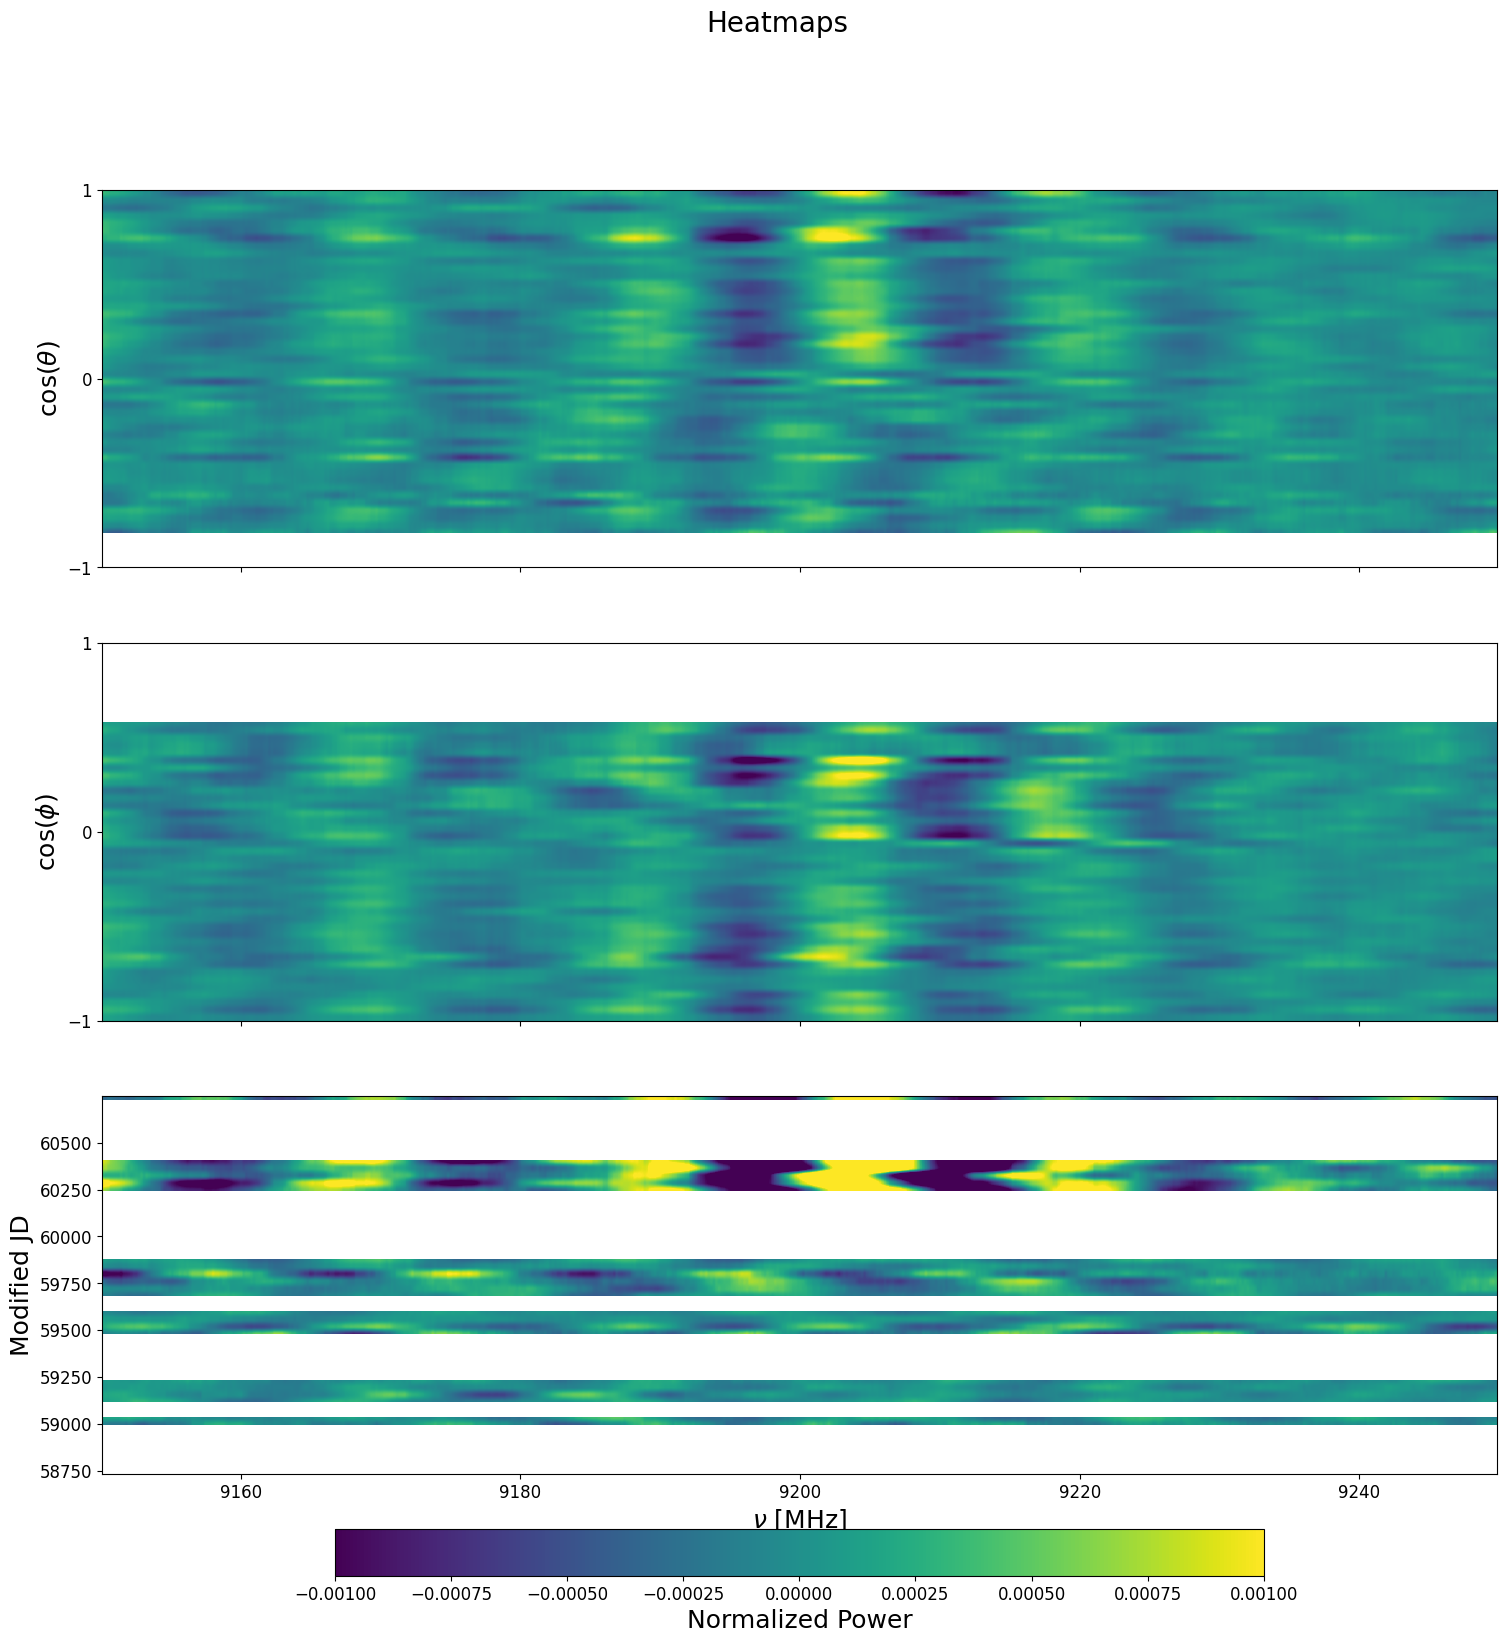

In [32]:
plot_heatmaps(info_trimmed, new_uninj_normalized_dir, freq=9200)

In [116]:
new_injected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/new/injected'

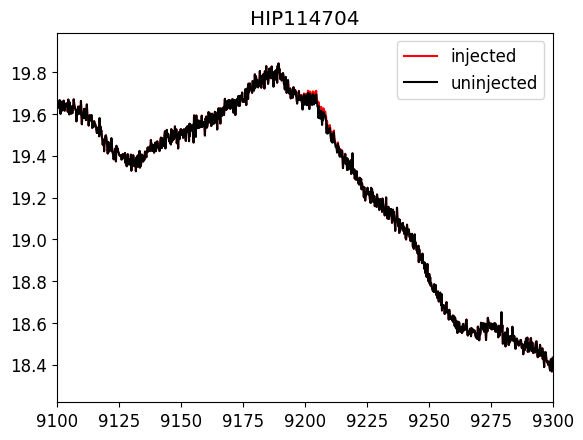

In [118]:
temp = info_trimmed[info_trimmed['time'].apply(lambda l: int(l.split('_')[0])) > 60250]
targ = 'HIP114704'#random.choice(list(temp['source']))
uninj = np.load(os.path.join(new_uninjected_dir, targ + '.npy'))
inj = np.load(os.path.join(new_injected_dir, targ + '.npy'))

plt.plot(*inj, c='r', label='injected')
plt.plot(*uninj, c='k', label='uninjected')

plt.xlim(9100, 9300)
ymin = np.min(uninj[1][np.argmin(np.abs(uninj[0]-9100)):np.argmin(np.abs(uninj[0]-9300))])
ymax = np.max(uninj[1][np.argmin(np.abs(uninj[0]-9100)):np.argmin(np.abs(uninj[0]-9300))])
ypad = 0.1 * (ymax - ymin)
plt.ylim(ymin-ypad, ymax+ypad)

plt.title(targ)
plt.legend()

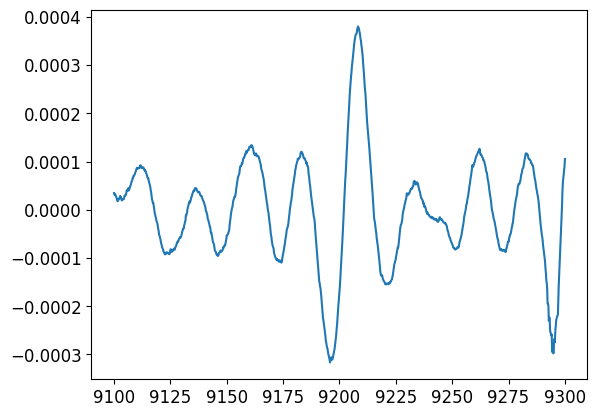

In [54]:
# Uninjected asymmetry with exterior=8 (original)
new_uninj_normalized_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/new/normalized_uninjected'

def normalize_new(targ):
    normalize_weighted_v2(
        targ,
        data_dir=new_uninjected_dir,
        save_dir=new_uninj_normalized_dir,
        exterior=8,
        freq=9200,
        width=100,
        b=1
    )

# with Pool(processes=10) as p:
#     _ = list(tqdm(p.imap_unordered(normalize_new, os.listdir(new_uninjected_dir)), total=len(os.listdir(new_uninjected_dir))))

xs, asymmetry = build_asymmetry_modified_v2(new_uninj_normalized_dir, 'phi', 70, 115)
plt.plot(xs, asymmetry)

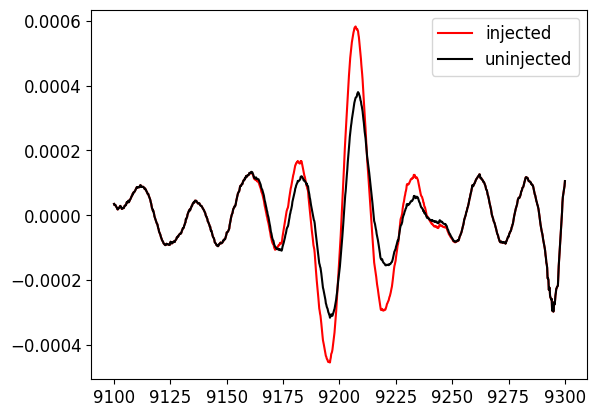

In [55]:
new_inj_normalized_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/new/normalized'
xs, uninj = build_asymmetry_modified_v2(new_uninj_normalized_dir, 'phi', 70, 115)
xs, inj = build_asymmetry_modified_v2(new_inj_normalized_dir, 'phi', 70, 115)

plt.plot(xs, inj, c='r', label='injected')
plt.plot(xs, uninj, c='k', label='uninjected')
plt.legend()

## Fine. 9100 MHz it is then.

In [56]:
freq = 9200
signal_size = 1e-29

100%|██████████| 4653/4653 [07:54<00:00,  9.82it/s]


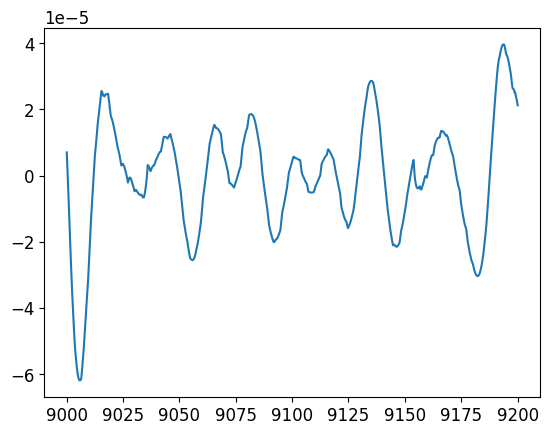

In [57]:
# Old method - using "preprocessed" spectra
uninjected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/preprocessed/1'
injected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/old/injected_9100'
normalized_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/old/normalized_9100'
calibration_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/median_sefds/1'

os.makedirs(injected_dir, exist_ok=True)
os.makedirs(normalized_dir, exist_ok=True)

def normalize(targ):
    inject_calibrated(
        targ,
        freq,
        info,
        data_dir=uninjected_dir,
        save_dir=injected_dir,
        calibration_dir=calibration_dir,
        signal_sizes=signal_size,
    )
    normalize_weighted(
        targ,
        data_dir=injected_dir,
        save_dir=normalized_dir,
        exterior=8,
        freq=9100,
        width=100
    )

with Pool(processes=10) as p:
    _ = list(tqdm(p.imap_unordered(normalize, os.listdir(uninjected_dir)), total=len(os.listdir(uninjected_dir))))

xs, asymmetry = build_asymmetry_modified(normalized_dir, 'phi', 70, 115)
plt.plot(xs, asymmetry)

  0%|          | 0/1892 [00:00<?, ?it/s]

100%|██████████| 1892/1892 [03:51<00:00,  8.17it/s]


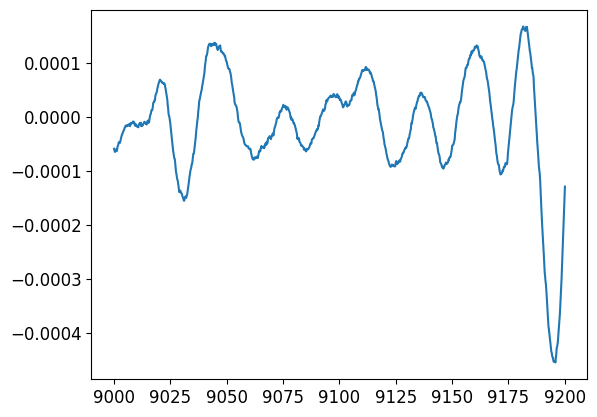

In [59]:
# New method - using "calibrated" spectra
uninjected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/calibrated/1'
injected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/new/injected_9100'
normalized_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/new/normalized_9100'

os.makedirs(injected_dir, exist_ok=True)
os.makedirs(normalized_dir, exist_ok=True)

def normalize(targ):
    inject_calibrated_v2(
        targ,
        freq,
        info,
        data_dir=uninjected_dir,
        save_dir=injected_dir,
        signal_sizes=signal_size,
    )
    normalize_weighted_v2(
        targ,
        data_dir=injected_dir,
        save_dir=normalized_dir,
        exterior=8,
        freq=9100,
        width=100
    )

with Pool(processes=10) as p:
    _ = list(tqdm(p.imap_unordered(normalize, os.listdir(uninjected_dir)), total=len(os.listdir(uninjected_dir))))

xs, asymmetry = build_asymmetry_modified_v2(normalized_dir, 'phi', 70, 115)
plt.plot(xs, asymmetry)

## Normalizing an SEFD - gain oscillations or not?!

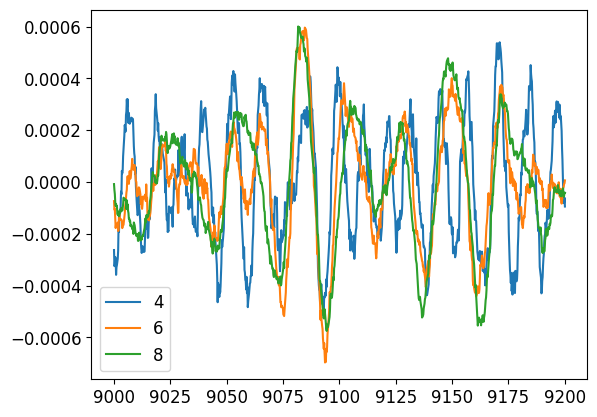

In [12]:
file = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_new/1/3C48/58733_45129/SEFD.npy'
spec = np.load(file)
norm_4 = normalize_weighted_v2(
    spec,
    exterior=4,
    freq=9100,
    width=100
)
norm_6 = normalize_weighted_v2(
    spec,
    exterior=6,
    freq=9100,
    width=100
)
norm_8 = normalize_weighted_v2(
    spec,
    exterior=8,
    freq=9100,
    width=100
)
plt.plot(*norm_4, label='4')
plt.plot(*norm_6, label='6')
plt.plot(*norm_8, label='8')

plt.legend()

### What about a flat line

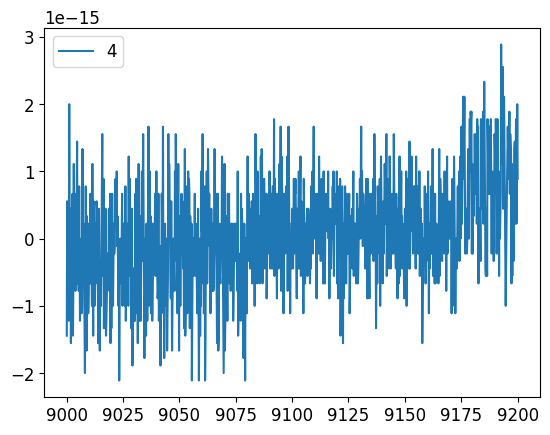

In [58]:
flat = [spec[0], np.ones_like(spec[1])]
norm_spec = normalize_weighted_v2(
    flat,
    exterior=4,
    freq=9100,
    width=100
)
# norm_spec_8 = normalize_weighted_v2(
#     flat,
#     exterior=8,
#     freq=9100,
#     width=100
# )
plt.plot(*norm_spec, label='4')
#plt.plot(*norm_spec_8, label='8')
plt.legend()
#plt.xlim(9090, 9110)

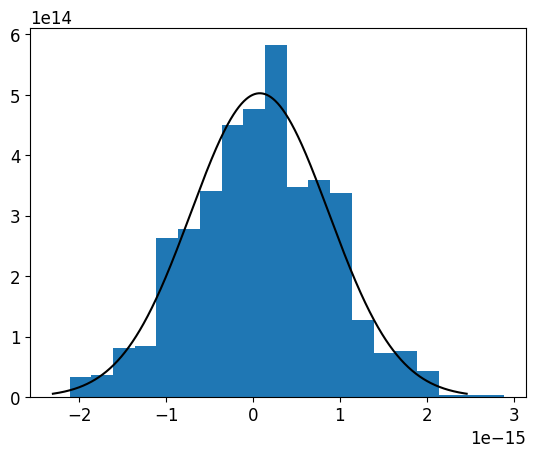

In [15]:
plt.hist(norm_spec[1], density=True, bins=20)
mean, std = np.mean(norm_spec[1]), np.std(norm_spec[1])
x = np.linspace(mean-3*std, mean+3*std, 1000)
p = norm.pdf(x, mean, std)
plt.plot(x, p, c='k')

### How about simulating Gaussian noise

In [16]:
noise = np.random.normal(0, 1, size=len(spec[1]))
noise

array([ 0.3443554 ,  0.54660508, -0.26310838, ..., -1.29737411,
        1.0800273 , -0.10025719])

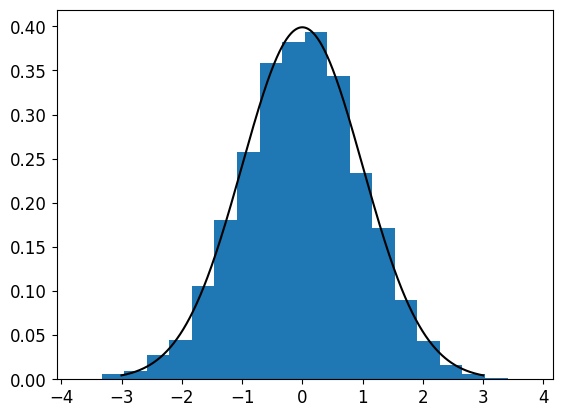

In [17]:
plt.hist(noise, density=True, bins=20)
x = np.linspace(-3, 3, 1000)
p = norm.pdf(x, 0, 1)
plt.plot(x, p, c='k')

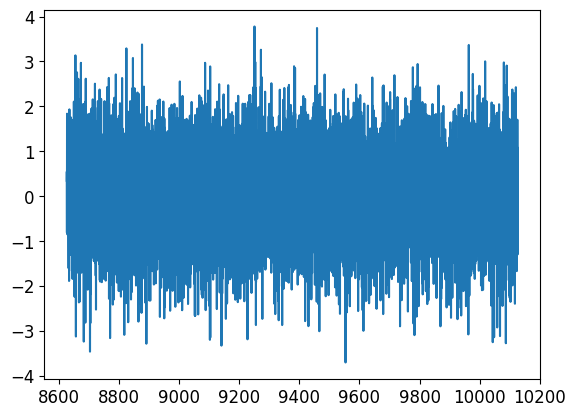

In [18]:
noisy_flat = np.array([spec[0], noise])
plt.plot(*noisy_flat)

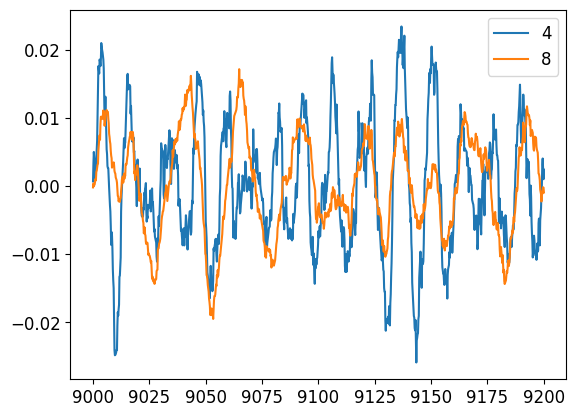

In [19]:
norm_spec = normalize_weighted_v2(
    noisy_flat,
    exterior=4,
    freq=9100,
    width=100
)
norm_spec_8 = normalize_weighted_v2(
    noisy_flat,
    exterior=8,
    freq=9100,
    width=100
)
plt.plot(*norm_spec, label='4')
plt.plot(*norm_spec_8, label='8')
plt.legend()

#plt.xlim(9090, 9100)

### What does a derived gain look like (where is the noise coming from?!)

(121686260.35982753, 185653733.7854362)

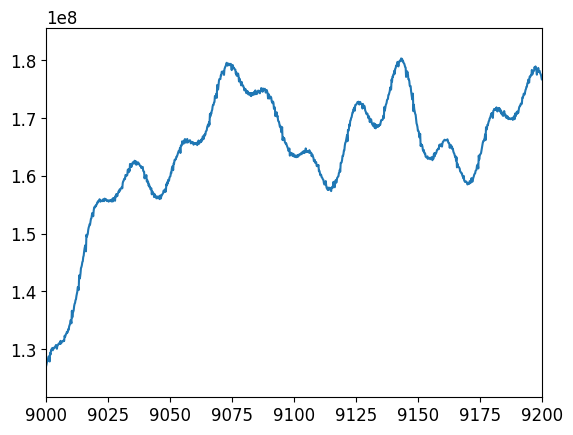

In [20]:
file = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_v2/1/AGBT19B_999_15/gain.npy'
gain = np.load(file)
plt.plot(*gain)
plt.xlim(9000, 9200)
ymin = np.min(gain[1][np.argmin(np.abs(gain[0]-9000)):np.argmin(np.abs(gain[0]-9200))])
ymax = np.max(gain[1][np.argmin(np.abs(gain[0]-9000)):np.argmin(np.abs(gain[0]-9200))])
ypad = 0.1 * (ymax - ymin)
plt.ylim(ymin-ypad, ymax+ypad)

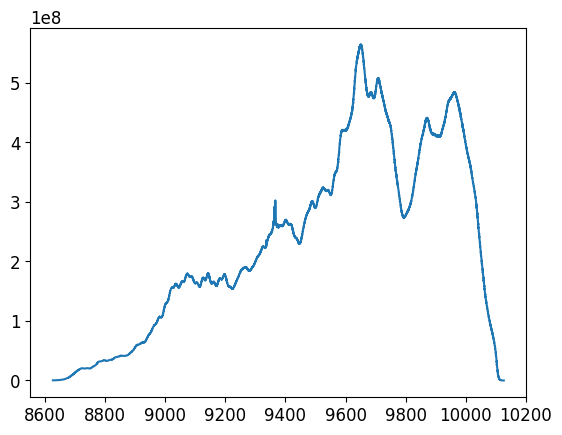

In [110]:
file = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_v2/1/AGBT19B_999_15/gain.npy'
gain = np.load(file)
plt.plot(*gain)

(2218125365.3127785, 3324365410.7031975)

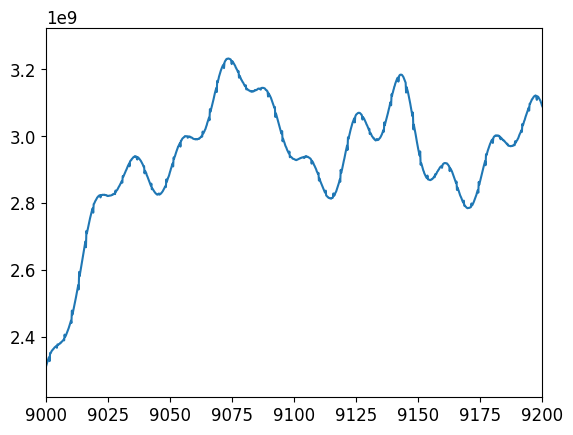

In [21]:
file = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_v2/1/AGBT19B_999_15/ON.npy'
on = np.load(file)
plt.plot(*on)
plt.xlim(9000, 9200)
ymin = np.min(on[1][np.argmin(np.abs(on[0]-9000)):np.argmin(np.abs(on[0]-9200))])
ymax = np.max(on[1][np.argmin(np.abs(on[0]-9000)):np.argmin(np.abs(on[0]-9200))])
ypad = 0.1 * (ymax - ymin)
plt.ylim(ymin-ypad, ymax+ypad)

(362715991.09347665, 545306612.0437843)

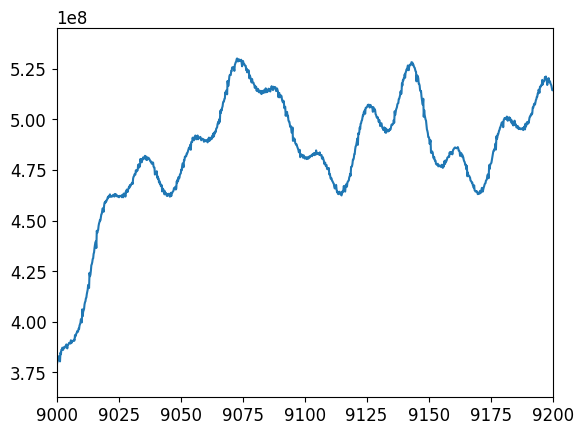

In [22]:
file = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_v2/1/AGBT19B_999_15/ON_OFF.npy'
on_off = np.load(file)
plt.plot(*on_off)
plt.xlim(9000, 9200)
ymin = np.min(on_off[1][np.argmin(np.abs(on_off[0]-9000)):np.argmin(np.abs(on_off[0]-9200))])
ymax = np.max(on_off[1][np.argmin(np.abs(on_off[0]-9000)):np.argmin(np.abs(on_off[0]-9200))])
ypad = 0.1 * (ymax - ymin)
plt.ylim(ymin-ypad, ymax+ypad)

### Does an SEFD have noise

13.154970863586907 13.858324300815243 0.07033534372283352


(13.084635519864074, 13.928659644538076)

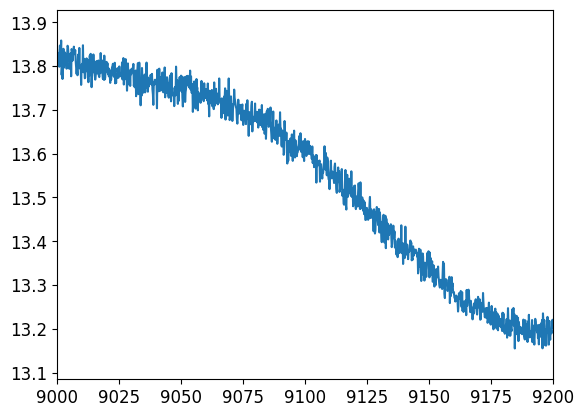

In [23]:
file = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_new/1/3C48/58733_45129/SEFD.npy'
spec = np.load(file)
plt.plot(*spec)
plt.xlim(9000, 9200)
ymin = np.min(spec[1][np.argmin(np.abs(spec[0]-9000)):np.argmin(np.abs(spec[0]-9200))])
ymax = np.max(spec[1][np.argmin(np.abs(spec[0]-9000)):np.argmin(np.abs(spec[0]-9200))])
ypad = 0.1 * (ymax - ymin)
print(ymin, ymax, ypad)
plt.ylim(ymin-ypad, ymax+ypad)

### Normalizing a fake spectrum - sinusoid

(9000.0, 9200.0)

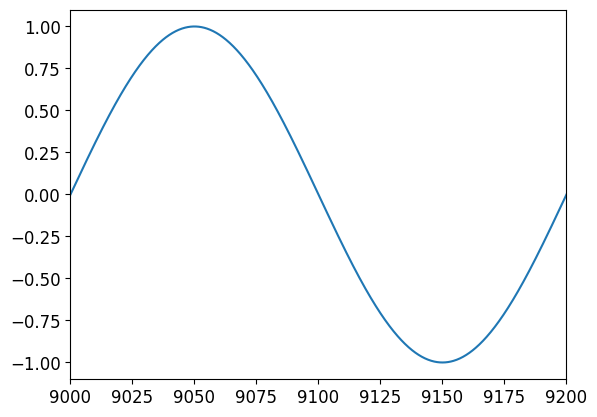

In [24]:
fake_spec = np.sin(2 * np.pi / 200 * spec[0])
plt.plot(spec[0], fake_spec)
plt.xlim(9000, 9200)

In [25]:
fake_spec = np.array([spec[0], fake_spec])

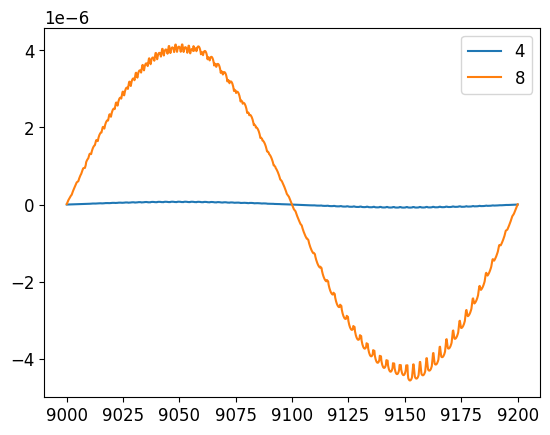

In [26]:
norm_spec = normalize_weighted_v2(
    fake_spec,
    exterior=4,
    freq=9100,
    width=100
)
norm_spec_8 = normalize_weighted_v2(
    fake_spec,
    exterior=8,
    freq=9100,
    width=100
)
plt.plot(*norm_spec, label='4')
plt.plot(*norm_spec_8, label='8')
plt.legend()

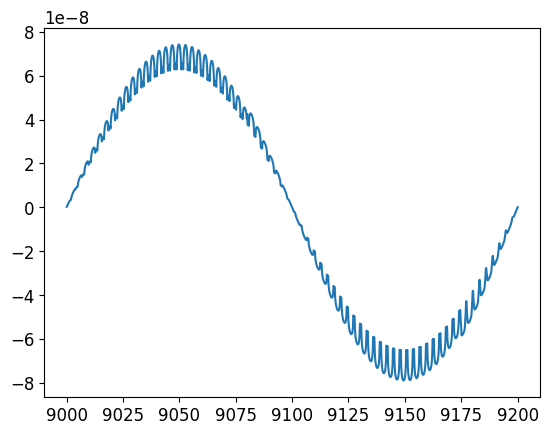

In [27]:
plt.plot(*norm_spec, label='4')

In [28]:
fake_noisy_spec = np.sin(2 * np.pi / 200 * spec[0]) + np.random.normal(0, 0.01, size=len(spec[0]))

(9000.0, 9200.0)

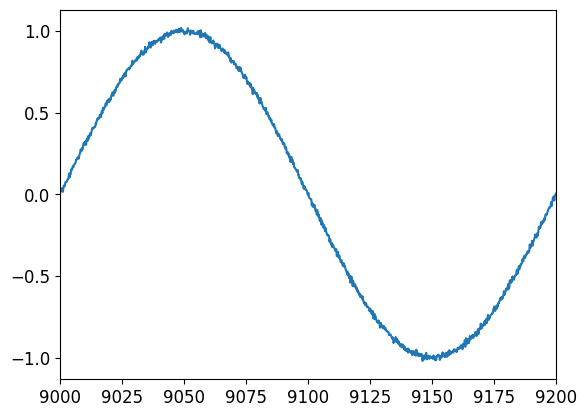

In [29]:
plt.plot(spec[0], fake_noisy_spec)
plt.xlim(9000,9200)

In [30]:
fake_noisy_spec = np.array([spec[0], fake_noisy_spec])

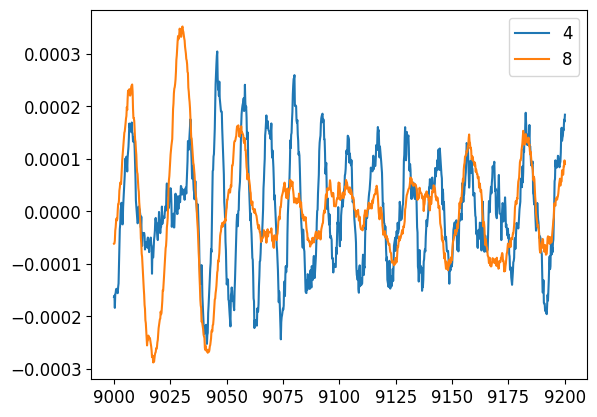

In [31]:
norm_spec = normalize_weighted_v2(
    fake_noisy_spec,
    exterior=4,
    freq=9100,
    width=100
)
norm_spec_8 = normalize_weighted_v2(
    fake_noisy_spec,
    exterior=8,
    freq=9100,
    width=100
)
plt.plot(*norm_spec, label='4')
plt.plot(*norm_spec_8, label='8')
plt.legend()

No bueno!

## Let's try smoothing with a savgol filter

(9000.0, 9200.0)

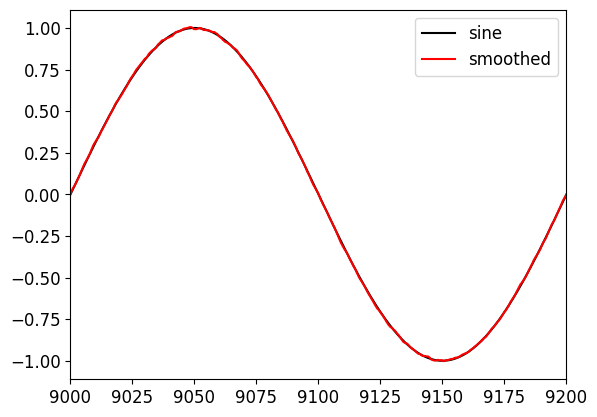

In [32]:
smooth = savgol_filter(fake_noisy_spec[1], 30, 4)
fake_noisy_spec_smooth = np.array([spec[0], smooth])
plt.plot(*fake_spec, c='k', label='sine')
plt.plot(*fake_noisy_spec_smooth, c='r', label='smoothed')
plt.legend()
plt.xlim(9000, 9200)

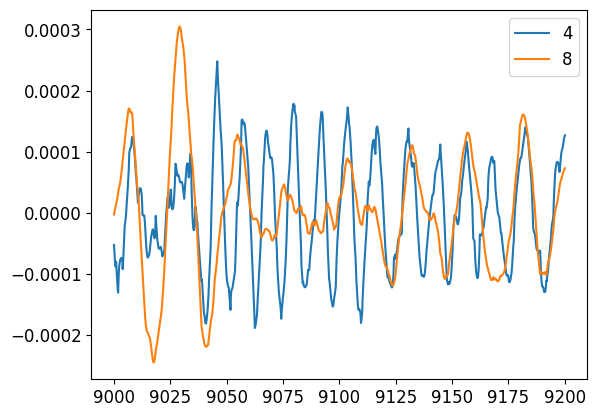

In [33]:
norm_spec = normalize_weighted_v2(
    fake_noisy_spec_smooth,
    exterior=4,
    freq=9100,
    width=100
)
norm_spec_8 = normalize_weighted_v2(
    fake_noisy_spec_smooth,
    exterior=8,
    freq=9100,
    width=100
)
plt.plot(*norm_spec, label='4')
plt.plot(*norm_spec_8, label='8')
plt.legend()

Changed nothing. It's just smoother now.

Let's try a larger window... (100 bins)

(9000.0, 9200.0)

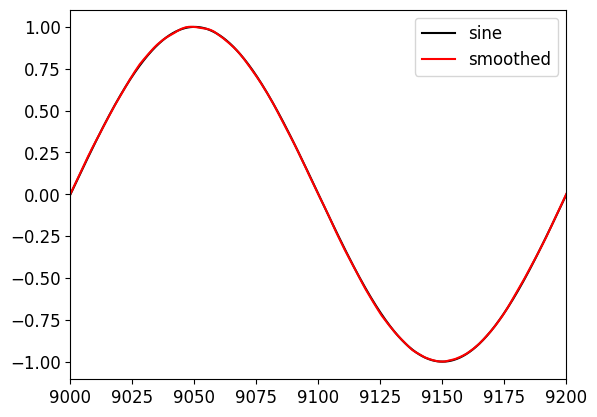

In [34]:
smooth = savgol_filter(fake_noisy_spec[1], 100, 4)
fake_noisy_spec_smooth = np.array([spec[0], smooth])
plt.plot(*fake_spec, c='k', label='sine')
plt.plot(*fake_noisy_spec_smooth, c='r', label='smoothed')
plt.legend()
plt.xlim(9000, 9200)

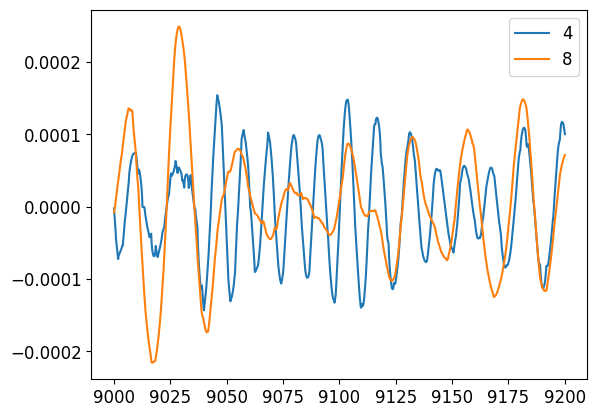

In [35]:
norm_spec = normalize_weighted_v2(
    fake_noisy_spec_smooth,
    exterior=4,
    freq=9100,
    width=100
)
norm_spec_8 = normalize_weighted_v2(
    fake_noisy_spec_smooth,
    exterior=8,
    freq=9100,
    width=100
)
plt.plot(*norm_spec, label='4')
plt.plot(*norm_spec_8, label='8')
plt.legend()

### The return of PG????

In [47]:
def normalize_dynamic_v2(data, data_dir=None, save_dir=None, interior=2, exterior=3, order=5, is_decay=True, **kwargs):
    if data_dir:
        xs, ys = np.load(os.path.join(data_dir, data))
    else:
        xs, ys = deepcopy(data)
    
    freq_diff = xs[1] - xs[0]
    xs, ys_mean = prepare(xs, ys, freq_diff, **kwargs)

    new_xs = []
    normalized_spectrum = []
    
    def get_sigma(center):
        if is_decay:
            sigma = v_virial*center/(c*np.sqrt(3))
        else:
            sigma = v_virial*center/(c*np.sqrt(6))
        return sigma
    
    def fit_func(x, A, center, *coeffs, window_center=0):
        ''' Polynomial plus Gaussian.'''
        sigma = get_sigma(window_center + center)
        y = (A**2)*np.exp((-(freq_diff*x-center)**2)/(2*sigma**2))
        y += fit_func2(x, *coeffs)
        return y

    def fit_func2(x, *coeffs): #polynomial
        '''Polynomial.'''
        y = 0
        for i, coeff in enumerate(coeffs):
            y += coeff * x ** i
        return y
    
    # Loop through the data points and divide each point by the polynomial 
    for i, x in enumerate(xs):
        window = round_up_to_nearest_odd(2 * exterior * get_sigma(x) / freq_diff)
        if i < (window//2):
            continue
        if i >= len(xs) - (window//2 + 1):
            break
        ind_xs = np.arange(-(window//2), window//2+1)
        #print(f'{i}/{len(xs)-upper-lower}')
        current_ys = ys_mean[i-window//2:i+window//2+1]
        idx = np.isfinite(current_ys)
        
        # Center bounds
        lower_bound = -(window//2) * freq_diff
        upper_bound = (window//2) * freq_diff
        #guesses = np.ones_like(range(order+1)).tolist()
        guesses = [1, *np.zeros(order)]
        bounds = (
            (-np.inf, lower_bound, *[-np.inf for _ in guesses]),
            (np.inf, upper_bound, *[np.inf for _ in guesses])
        )
        
        # Fit the defined function to the data using curve fitting
        fit_func_wrapper = partial(fit_func, window_center=x)
        #polynomial + gaussian
        parameters, covariance = curve_fit(
            fit_func_wrapper,
            ind_xs[idx],
            current_ys[idx],
            p0=[0.1, 0, *guesses],
            bounds=bounds,
            maxfev=1000000)

        # cent = ind_xs[np.argmin(np.abs(ind_xs-fit_center_/freq_diff))]
        fit_center_ = parameters[1]
        cent = fit_center_/freq_diff
        sig = interior * get_sigma(x + fit_center_)/freq_diff # 3 sigma 
        mask1 = ind_xs[idx] < (cent - sig)
        mask2 = ind_xs[idx] > (cent + sig)
        combined_mask = mask1 | mask2
        xs_masked = ind_xs[idx][combined_mask]
        ys_masked = current_ys[idx][combined_mask]
        
        #parameters2, covariance = curve_fit(fit_func2, xs_masked, ys_masked, p0=guesses, maxfev=1000000)
        parameters2 = np.polyfit(xs_masked, ys_masked, order)
        
        #p = fit_func2(0, *parameters2)
        p = np.poly1d(parameters2)(0)
        pg = fit_func_wrapper(0, *parameters)
        new_xs.append(x)
        normalized_spectrum.append(pg-p) # subtracting instead of dividing
        
        del current_ys, parameters, parameters2
           
    normalized = np.array([new_xs, normalized_spectrum])
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        np.save(os.path.join(save_dir, data), normalized)
        
    return normalized


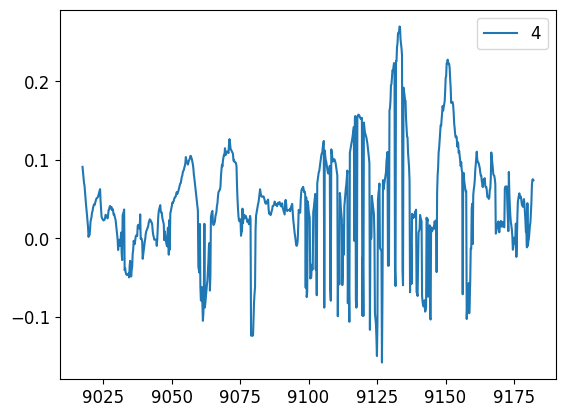

In [48]:
norm_spec = normalize_dynamic_v2(
    fake_noisy_spec_smooth,
    interior=1.4,
    exterior=4,
    freq=9100,
    width=100
)
# norm_spec_8 = normalize_dynamic_v2(
#     fake_noisy_spec_smooth,
#     interior=1.4,
#     exterior=8,
#     freq=9100,
#     width=100
# )
plt.plot(*norm_spec, label='4')
#plt.plot(*norm_spec_8, label='8')
plt.legend()

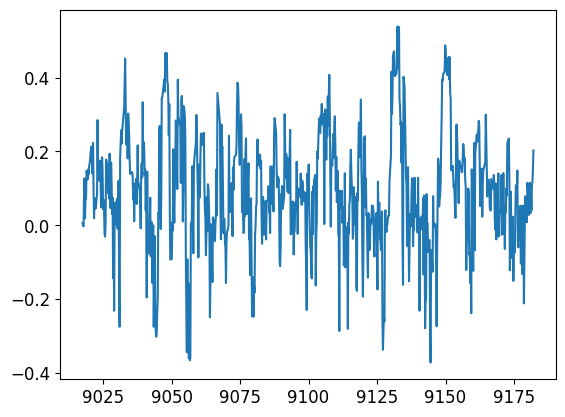

In [49]:
norm_spec = normalize_dynamic_v2(
    fake_noisy_spec,
    interior=1.4,
    exterior=4,
    freq=9100,
    width=100
)
plt.plot(*norm_spec, label='4')

## Compare noise - (ON-OFF)/Tcal vs. OFF/(Tsys+Tsky)

13.264468699372856
161669323.95774317 173712505.00039992 1204318.104265675


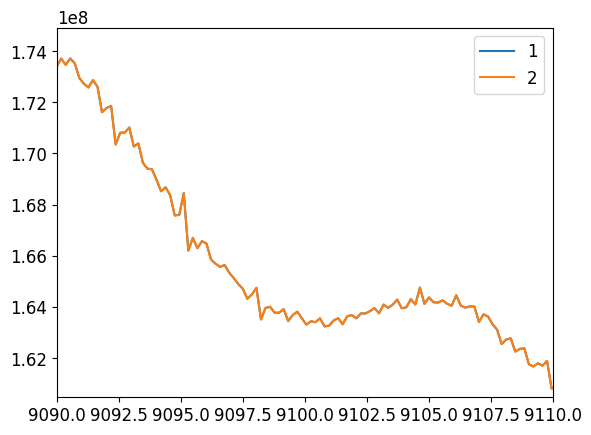

In [ ]:
gain = np.load('/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_v2/1/AGBT19B_999_15/gain.npy')

on = np.load('/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_v2/1/AGBT19B_999_15/ON.npy')
off = np.load('/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_v2/1/AGBT19B_999_15/OFF.npy')
sefd = np.load('/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_new/1/3C48/58733_45129/SEFD.npy')

k = 1.38e-23  # Boltzmann constant in J/K
JY_PER_J = 1e26 # Jy per Joule

a_eff = 0.7 * np.pi * 50**2
Tsky = 2.728

S = sefd[1] + (2 * k * JY_PER_J) / a_eff * Tsky
#S = flux_jy(off[0], '3C48') * (off[1]) / (on[1] - off[1])
print(np.median(sefd[1]))
gain2 = np.array([sefd[0], off[1] / S])

plt.plot(*gain, label='1')
plt.plot(*gain2, label='2')

def set_lims(lim1, lim2):
    plt.xlim(lim1, lim2)
    ymin = np.min(gain[1][np.argmin(np.abs(gain[0]-lim1)):np.argmin(np.abs(gain[0]-lim2))])
    ymax = np.max(gain[1][np.argmin(np.abs(gain[0]-lim1)):np.argmin(np.abs(gain[0]-lim2))])
    ypad = 0.1 * (ymax - ymin)
    print(ymin, ymax, ypad)
    plt.ylim(ymin-ypad, ymax+ypad)

set_lims(9090, 9110)
plt.legend()

# div = np.array([gain[0], gain[1]/gain2[1]])
# plt.plot(*div)

They are in exact agreement (not shocking at all)

### What about over the course of a session

Text(0.5, 1.0, 'AGBT19B_999_15')

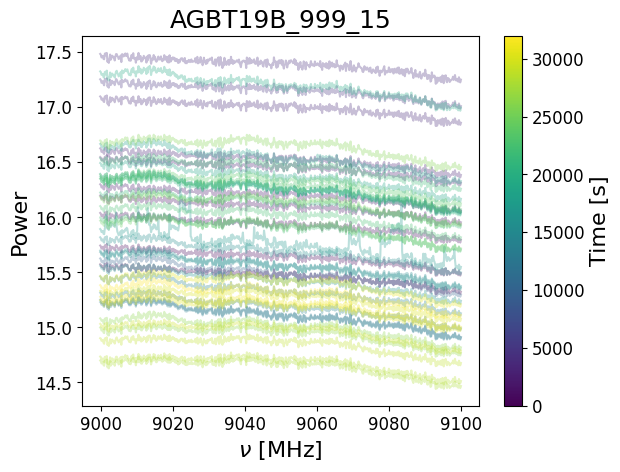

In [97]:
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/calibrated/1'
epoch = 'AGBT19B_999_15'

temp = info[info['epoch'] == epoch]
times = temp['time'].apply(convert_to_seconds)
times = np.array([time - min(times) for time in times])
indices = np.argsort(times)
times = times[indices]
names = temp['source'].to_numpy()[indices]

cmap = mpl.colormaps['viridis']
norm = mpl.colors.Normalize(vmin=min(times), vmax=max(times))

fig, ax = plt.subplots()
for name, time in zip(names, times):
    path = os.path.join(data_dir, name + '.npy')
    if os.path.exists(path):
        spec = np.load(path)
        spec = spec[:, np.argmin(np.abs(spec[0]-9000)):np.argmin(np.abs(spec[0]-9100))]
        ax.plot(*spec, color=cmap(norm(time)), alpha=0.3)
cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label('Time [s]', fontsize=16)

ax.set_xlabel(r'$\nu$ [MHz]', fontsize=16)
ax.set_ylabel('Power', fontsize=16)
ax.set_title(epoch, fontsize=18)

In [90]:
sorted(temp['time'])

['58733_47224',
 '58733_47872',
 '58733_48438',
 '58733_48756',
 '58733_49385',
 '58733_50017',
 '58733_50419',
 '58733_50735',
 '58733_51367',
 '58733_52004',
 '58733_52866',
 '58733_53502',
 '58733_54134',
 '58733_55503',
 '58733_56150',
 '58733_57004',
 '58733_59553',
 '58733_60724',
 '58733_61048',
 '58733_61679',
 '58733_62314',
 '58733_62648',
 '58733_62963',
 '58733_63606',
 '58733_64257',
 '58733_64789',
 '58733_65103',
 '58733_65736',
 '58733_66371',
 '58733_67355',
 '58733_67671',
 '58733_68309',
 '58733_68946',
 '58733_69298',
 '58733_69619',
 '58733_70259',
 '58733_70897',
 '58733_71453',
 '58733_72417',
 '58733_73055',
 '58733_73525',
 '58733_73847',
 '58733_75132',
 '58733_75653',
 '58733_75968',
 '58733_76600',
 '58733_77231',
 '58733_77577',
 '58733_77898',
 '58733_78535',
 '58733_79175']

(array([7., 5., 3., 2., 6., 6., 5., 5., 6., 6.]),
 array([5.07457842e+09, 5.07458162e+09, 5.07458481e+09, 5.07458801e+09,
        5.07459120e+09, 5.07459440e+09, 5.07459759e+09, 5.07460079e+09,
        5.07460398e+09, 5.07460718e+09, 5.07461038e+09]),
 <BarContainer object of 10 artists>)

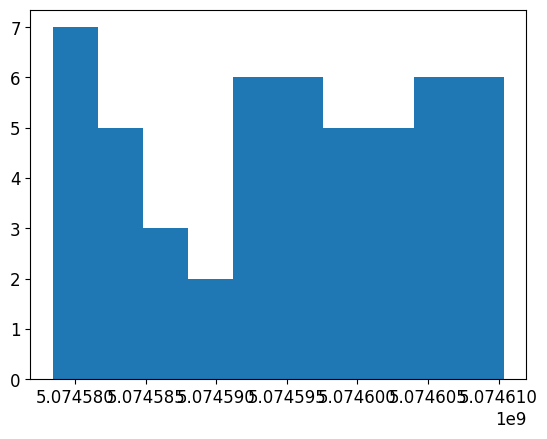

In [91]:
plt.hist(temp['time'].apply(convert_to_seconds))

## Noise vs. non-noise - asymmetry simulations

In [95]:
def generate_random_spectrum():
    freqs = np.load('/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_new/1/3C48/58733_45129/SEFD.npy')[0]
    A = np.random.normal(0, 0.01)
    phi = np.random.normal(0, np.pi / 4)
    spec = A * np.sin(2 * np.pi / 20 * freqs - phi)
    # if noise:
    #     noise = np.random.normal(0, 0.005, size=len(spec))
    #     return np.array([freqs, spec + noise])
    return np.array([freqs, spec])

fake_dataset = [generate_random_spectrum() for _ in range(1000)]

(9000.0, 9200.0)

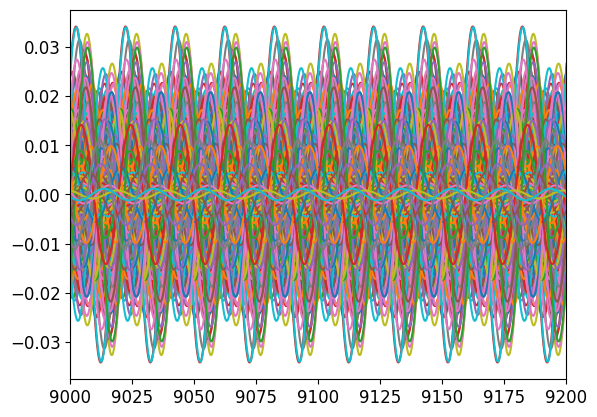

In [96]:
for data in fake_dataset:
    plt.plot(*data)
plt.xlim(9000,9200)

In [98]:
noisy_fake_dataset = [
    np.array([data[0], data[1] + np.random.normal(0, 0.005, size=len(data[1]))])
    for data in fake_dataset
]

(9000.0, 9200.0)

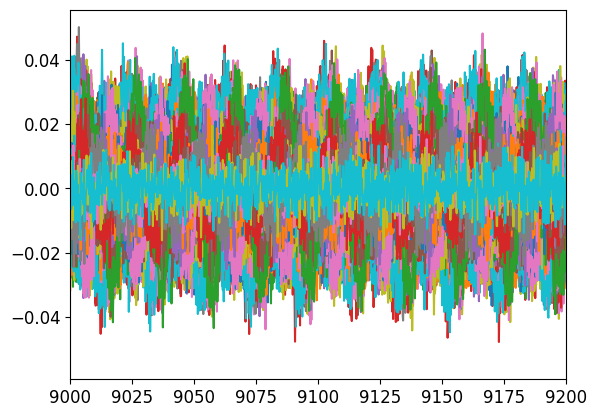

In [99]:
for data in noisy_fake_dataset:
    plt.plot(*data)
plt.xlim(9000,9200)

In [100]:
def build_fake_asymmetry(dataset):
    N = len(dataset)
    inner_spectra = np.array([data[1] for data in dataset[:N//2]])
    outer_spectra = np.array([data[1] for data in dataset[N//2:]])
    inner_mean = np.mean(inner_spectra, axis=0)
    outer_mean = np.mean(outer_spectra, axis=0)
    asymmetry = (inner_mean - outer_mean) / (inner_mean + outer_mean + 2)
    xs = dataset[0][0]
    return xs, asymmetry

100%|██████████| 1000/1000 [01:54<00:00,  8.70it/s]


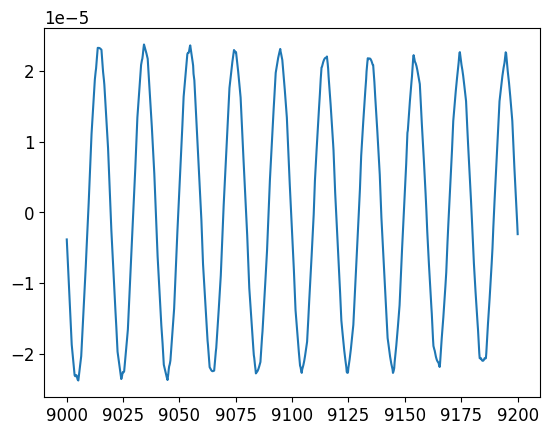

In [103]:
def normalize(data):
    return normalize_weighted_v2(
        data,
        exterior=8,
        freq=9100,
        width=100
    )
with Pool(processes=10) as p:
    normalized = list(tqdm(p.imap_unordered(normalize, fake_dataset), total=len(fake_dataset)))

xs, asymmetry = build_fake_asymmetry(normalized)
plt.plot(xs, asymmetry)

100%|██████████| 1000/1000 [01:54<00:00,  8.74it/s]


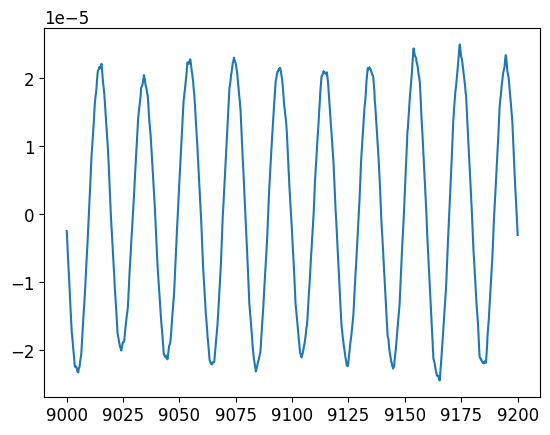

In [104]:
with Pool(processes=10) as p:
    normalized_noisy = list(tqdm(p.imap_unordered(normalize, noisy_fake_dataset), total=len(noisy_fake_dataset)))

xs, asymmetry_noisy = build_fake_asymmetry(normalized_noisy)
plt.plot(xs, asymmetry_noisy)

In [107]:
# One last test: flat Gaussian noise
freqs = np.load('/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_new/1/3C48/58733_45129/SEFD.npy')[0]
noisy_flat_fake_dataset = [
    np.array([freqs, np.random.normal(0, 0.005, size=len(freqs))])
    for _ in range(1000)
]

100%|██████████| 1000/1000 [01:54<00:00,  8.75it/s]


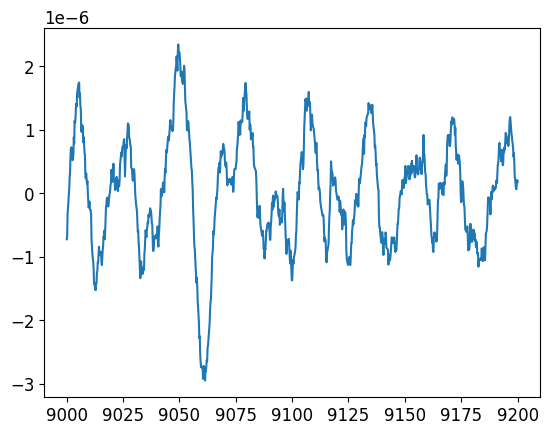

In [108]:
with Pool(processes=10) as p:
    normalized_flat = list(tqdm(p.imap_unordered(normalize, noisy_flat_fake_dataset), total=len(noisy_flat_fake_dataset)))

xs, asymmetry_flat = build_fake_asymmetry(normalized_flat)
plt.plot(xs, asymmetry_flat)

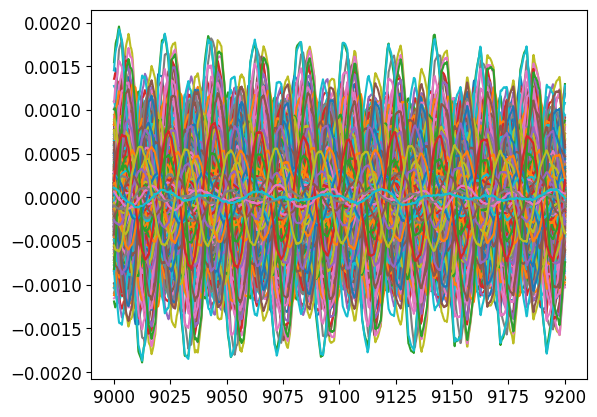

In [109]:
for data in normalized_noisy:
    plt.plot(*data)

# **V. Additional Studies**

## Gaussian noise asymmetry for large sample sizes

100%|██████████| 5000/5000 [09:29<00:00,  8.78it/s]


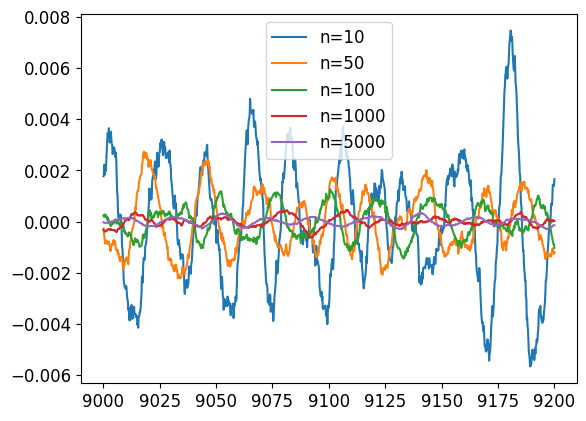

In [15]:
freqs = np.load('/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_new/1/3C48/58733_45129/SEFD.npy')[0]
def normalize(data):
    return normalize_weighted_v2(
        data,
        exterior=8,
        freq=9100,
        width=100
    )

def build_fake_asymmetry(dataset):
    N = len(dataset)
    inner_spectra = np.array([data[1] for data in dataset[:N//2]])
    outer_spectra = np.array([data[1] for data in dataset[N//2:]])
    inner_mean = np.mean(inner_spectra, axis=0)
    outer_mean = np.mean(outer_spectra, axis=0)
    asymmetry = (inner_mean - outer_mean) / (inner_mean + outer_mean + 2)
    xs = dataset[0][0]
    return xs, asymmetry

for n in [10, 50, 100, 1000, 5000]:
    fake_dataset = [
        np.array([freqs, np.random.normal(0, 1, size=len(freqs))])
        for _ in range(n)
    ]

    with Pool(processes=10) as p:
        normalized = list(tqdm(p.imap_unordered(normalize, fake_dataset), total=len(fake_dataset)))
    
    xs, asymmetry = build_fake_asymmetry(normalized)
    plt.plot(xs, asymmetry, label=f'n={n}')

plt.legend()

## New normalized spectra pdf

In [17]:
def plot_epoch_normalized_spectra(epoch):
    data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/new/normalized_9100'

    temp = info[info['epoch'] == epoch]
    times = temp['time'].apply(convert_to_seconds)
    times = np.array([time - min(times) for time in times])
    indices = np.argsort(times)
    times = times[indices]
    names = temp['source'].to_numpy()[indices]

    cmap = mpl.colormaps['viridis']
    norm = mpl.colors.Normalize(vmin=min(times), vmax=max(times))

    fig, ax = plt.subplots(figsize=(15,6))
    ypbots = []
    yptops = []
    for name, time in zip(names, times):
        path = os.path.join(data_dir, name + '.npy')
        if os.path.exists(path):
            spec = np.load(path)
            ax.plot(*spec, color=cmap(norm(time)), alpha=0.3, rasterized=True)
            ypbots.append(np.percentile(spec[1], 0))
            yptops.append(np.percentile(spec[1], 100))
    
    ypbot = np.percentile(ypbots, 0)
    yptop = np.percentile(yptops, 100)
    ypad = 0.1 * (yptop - ypbot)

    ax.set_xlim(min(spec[0]), max(spec[0]))
    ax.set_ylim(ypbot-ypad, yptop+ypad)

    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
    cbar.set_label('Time [s]', fontsize=16)

    ax.set_xlabel(r'$\nu$ [MHz]', fontsize=16)
    ax.set_ylabel('Normalized Flux Density [Jy]', fontsize=16)
    ax.set_title(epoch, fontsize=18)

    ax.xaxis.set_minor_locator(tck.MultipleLocator(100))

    return fig

plt.rcParams['path.simplify'] = True
plt.rcParams['path.simplify_threshold'] = 0.5

from matplotlib.backends.backend_pdf import PdfPages

pdf = PdfPages('/home/dataadmin/GBTData/SharedDataDirectory/normalized_spectra.pdf')

for epoch in calibrator_epochs:
    fig = plot_epoch_normalized_spectra(epoch)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

pdf.close()

## Gaussian noise contribution?

In [23]:
cadence_group['AGBT19B_999_106']['ON'][1].split('_')[-2]

'3C295'

In [25]:
info_trimmed['source']

1        HIP38468
2       HIP116538
3        HIP96264
58       HIP82993
59       HIP82871
          ...    
4994      HIP6529
4995      HIP5701
4996      HIP5777
4997      HIP5965
4998      HIP5673
Name: source, Length: 1979, dtype: object

In [28]:
info_trimmed['source'].tolist().index('HIP82993')

3

In [40]:
def get_sefd(name):
    epoch = info_trimmed.loc[info_trimmed['source'] == name, 'epoch'].iloc[0]
    calibrator_path = f'/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_v2/1/{epoch}'
    on_off = np.load(os.path.join(calibrator_path, 'ON_OFF.npy'))
    off = np.load(os.path.join(calibrator_path, 'OFF.npy'))
    targ = cadence_group[epoch]['ON'][1].split('_')[-2]
    S = flux_jy(off[0], targ) * off[1] / on_off[1]
    return np.array([off[0], S])

sefd_dataset = list(map(get_sefd, info_trimmed['source']))

freqs = np.load('/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_new/1/3C48/58733_45129/SEFD.npy')[0]
def normalize(name):
    data = sefd_dataset[info_trimmed['source'].tolist().index(name)]
    norm_spec = normalize_weighted_v2(
        data,
        exterior=8,
        freq=9100,
        width=100
    )
    save_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/new/normalized_uninjected_sefds'
    os.makedirs(save_dir, exist_ok=True)
    np.save(os.path.join(save_dir, name), norm_spec)

with Pool(processes=10) as p:
    normalized_sefds = list(tqdm(p.imap_unordered(normalize, info_trimmed['source']), total=len(info_trimmed['source'])))

100%|██████████| 1979/1979 [03:54<00:00,  8.44it/s]


In [41]:
def build_asymmetry_modified_v2(data_dir, angle, lower, upper, spectra=None):
    if spectra is None:
        spectra = os.listdir(data_dir)
    
    inner_pre = info[(info[angle] < lower) & (info['time'].apply(lambda t: convert_to_seconds(t) < 5.18e9))]
    inner_post = info[(info[angle] < lower) & (info['time'].apply(lambda t: convert_to_seconds(t) >= 5.18e9))]
    outer_pre = info[(info[angle] > upper) & (info['time'].apply(lambda t: convert_to_seconds(t) < 5.18e9))]
    outer_post = info[(info[angle] > upper) & (info['time'].apply(lambda t: convert_to_seconds(t) >= 5.18e9))]

    inner_pre_spectra = [np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in inner_pre['source'].tolist()]
    inner_post_spectra = [np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in inner_post['source'].tolist()]
    outer_pre_spectra = [np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in outer_pre['source'].tolist()]
    outer_post_spectra = [np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in outer_post['source'].tolist()]

    inner_pre_mean = np.mean(inner_pre_spectra, axis=0)
    inner_post_mean = np.mean(inner_post_spectra, axis=0)
    outer_pre_mean = np.mean(outer_pre_spectra, axis=0)
    outer_post_mean = np.mean(outer_post_spectra, axis=0)

    asymmetry = (inner_pre_mean + inner_post_mean - outer_pre_mean - outer_post_mean) / (inner_pre_mean + inner_post_mean + outer_pre_mean + outer_post_mean + 4)
    xs = np.load(os.path.join(data_dir, spectra[0]))[0]
    asymmetry = sigma_filter(asymmetry)
    return xs, asymmetry

In [46]:
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/calibrated/1'
def normalize(name):
    normalize_weighted_v2(
        name,
        data_dir=data_dir,
        save_dir='/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/new/normalized_uninjected_9100',
        exterior=8,
        freq=9100,
        width=100
    )

with Pool(processes=10) as p:
    _ = list(tqdm(p.imap_unordered(normalize, os.listdir(data_dir)), total=len(os.listdir(data_dir))))

100%|██████████| 1892/1892 [03:42<00:00,  8.51it/s]


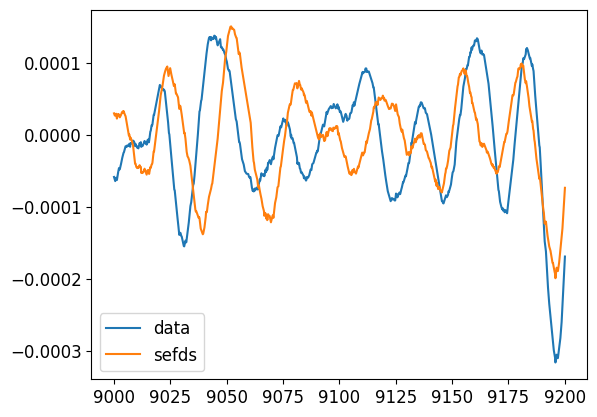

In [47]:
real_data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/new/normalized_uninjected_9100'
sefd_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibration_v2_test/new/normalized_uninjected_sefds'

xs, asymmetry = build_asymmetry_modified_v2(real_data_dir, 'phi', 70, 115)
xs, asymmetry_sefds = build_asymmetry_modified_v2(sefd_dir, 'phi', 70, 115)

plt.plot(xs, asymmetry, label='data')
plt.plot(xs, asymmetry_sefds, label='sefds')
plt.legend()

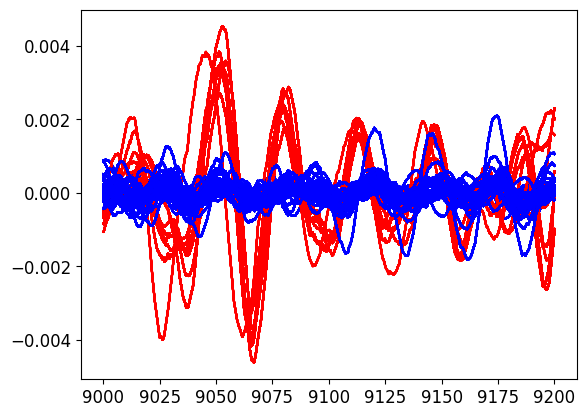

In [66]:
for name in os.listdir(sefd_dir):
    targ = name.replace('.npy', '')
    epoch = info_trimmed.loc[info_trimmed['source'] == targ, 'epoch'].iloc[0]
    year = int(epoch.split('_')[0][4:-1])
    if year > 22:
        color = 'r'
    else:
        color = 'b'
    data = np.load(os.path.join(sefd_dir, name))
    plt.plot(*data, c=color)

# **VI. Last Investigation: Instrumental Temperature Removal**

In [52]:
def get_reduced_spectrum(data_dir, calibration_dir, name):
    epoch = info_trimmed.loc[info_trimmed['source'] == name, 'epoch'].iloc[0]
    calibrator_path = os.path.join(calibration_dir, epoch)
    on_off = np.load(os.path.join(calibrator_path, 'ON_OFF.npy'))
    off = np.load(os.path.join(calibrator_path, 'OFF.npy'))
    targ = cadence_group[epoch]['ON'][1].split('_')[-2]
    S = flux_jy(off[0], targ) * off[1] / on_off[1]
    spec = np.load(os.path.join(data_dir, name + '.npy'))
    return np.array([spec[0], spec[1] - S])

In [55]:
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/calibrated'
calibration_path = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_v2/'
path_to_save = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/reduced'

for name in tqdm(info_trimmed['source']):
    for bank in range(3):
        data_path = os.path.join(data_dir, str(bank))
        sefd_path = os.path.join(calibration_path, str(bank))
        
        if os.path.exists(os.path.join(data_path, name + '.npy')):
            reduced = get_reduced_spectrum(data_path, sefd_path, name)
            save_dir = os.path.join(path_to_save, str(bank))
            os.makedirs(save_dir, exist_ok=True)
            np.save(os.path.join(save_dir, name), reduced)

100%|██████████| 1979/1979 [00:36<00:00, 54.32it/s] 


In [56]:
def plot_epoch_reduced_spectra(epoch):
    data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/reduced'

    temp = info[info['epoch'] == epoch]
    times = temp['time'].apply(convert_to_seconds)
    times = np.array([time - min(times) for time in times])
    indices = np.argsort(times)
    times = times[indices]
    names = temp['source'].to_numpy()[indices]

    cmap = mpl.colormaps['viridis']
    norm = mpl.colors.Normalize(vmin=min(times), vmax=max(times))

    fig, ax = plt.subplots(figsize=(15,6))
    ypbots = []
    yptops = []
    for name, time in zip(names, times):
        for bank in range(3):
            path = os.path.join(data_dir, str(bank), name + '.npy')
            if os.path.exists(path):
                spec = np.load(path)
                ax.plot(*spec, color=cmap(norm(time)), alpha=0.3, rasterized=True)
                ypbots.append(np.percentile(spec[1], 5))
                yptops.append(np.percentile(spec[1], 95))
    
    ypbot = np.percentile(ypbots, 5)
    yptop = np.percentile(yptops, 95)
    ypad = 0.1 * (yptop - ypbot)

    ax.set_ylim(ypbot-ypad, yptop+ypad)

    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
    cbar.set_label('Time [s]', fontsize=16)

    ax.set_xlabel(r'$\nu$ [MHz]', fontsize=16)
    ax.set_ylabel('$S$ [Jy]', fontsize=16)
    ax.set_title(epoch, fontsize=18)

    ax.xaxis.set_minor_locator(tck.MultipleLocator(100))

    return fig

plt.rcParams['path.simplify'] = True
plt.rcParams['path.simplify_threshold'] = 0.5

from matplotlib.backends.backend_pdf import PdfPages

pdf = PdfPages('/home/dataadmin/GBTData/SharedDataDirectory/reduced_spectra.pdf')

for epoch in calibrator_epochs:
    fig = plot_epoch_reduced_spectra(epoch)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

pdf.close()